# Predicting Household Purchasing Power from Spending Patterns
## MSIN0097 Predictive Analytics — Individual Coursework 2025-26

**Dataset**: Living Costs and Food Survey (LCFS), UK Data Service (2021-2023)  
**Task**: Multi-class classification — predict household purchasing power tier (equivalised income quintile) from expenditure and demographic features  
**Agent tool**: Claude Code (Claude Opus 4.6)

---

### Setup and Imports

This cell loads all required libraries and custom modules:
- **Data handling**: `numpy`, `pandas` for array/dataframe operations
- **Visualisation**: `matplotlib`, `seaborn` for plots with a colourblind-friendly palette
- **Machine learning**: `scikit-learn` models (Logistic Regression, Random Forest, Gradient Boosting), preprocessing, and evaluation utilities
- **Custom modules** (from `src/`):
  - `data_loader` — loads and merges LCFS survey data across years, computes equivalised income
  - `preprocessing` — target creation, feature selection, train/val/test splitting, PCA
  - `evaluation` — metrics printing, confusion matrix, calibration curves, feature importance plots

A global `RANDOM_STATE = 42` ensures reproducibility across all random operations.

In [1]:
# Core imports
# TensorFlow environment settings (must be set before import)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.data_loader import (
    load_lcfs_data, get_feature_columns,
    EXPENDITURE_FEATURES, DEMOGRAPHIC_FEATURES, LEAKAGE_VARIABLES,
    compute_oecd_scale, compute_equivalised_income,
)
from src.preprocessing import create_target, get_available_features, build_preprocessor, split_data, split_data_temporal, apply_pca
from src.evaluation import (
    print_classification_metrics, plot_confusion_matrix,
    plot_model_comparison, plot_feature_importance,
    plot_learning_curves, plot_calibration, QUINTILE_LABELS
)

# Plot settings
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output directories
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1. Obtain a Dataset and Frame the Predictive Problem

#### Dataset
The **Living Costs and Food Survey (LCFS)** is the UK's primary source of household expenditure data, collected by the Office for National Statistics. We use three survey years (2021-2023), providing ~14,000 households.

#### Predictive Problem
**Can we predict a household's purchasing power tier from its spending patterns and demographics?**

We define *purchasing power* as **equivalised income** — household income divided by the OECD modified equivalence scale, which adjusts for household size and composition. This is a better measure than raw income because a single person earning £500/week has more purchasing power than a family of four earning the same amount.

This reverses the usual direction of analysis (income → spending) and is relevant for:
- Identifying low-purchasing-power households from observable spending behaviour
- Policy targeting when direct income data is unavailable

#### Definitions
- **Target**: Equivalised income (`anon_income ÷ OECD scale`) binned into 5 quintiles (Q1=lowest purchasing power, Q5=highest)
- **OECD modified equivalence scale**: 1 + 0.5 × (additional adults) + 0.3 × (children under 14)
- **Prediction type**: Multi-class classification (5 classes)
- **Success metrics**: Macro F1-score (primary — treats all quintiles equally), accuracy (secondary)
- **Constraints**: No use of income-derived variables (leakage prevention)

#### Assumptions and Limitations
- Self-reported expenditure data may contain measurement error
- Survey weights (`weighta`) are not used as predictors but acknowledge sampling design
- UK-specific; results may not generalise internationally
- Anonymised income has been perturbed for disclosure control

#### Agent Tooling Plan
- **Agent tasks**: code scaffolding, EDA plot generation, pipeline construction, model comparison, debugging
- **My verification**: leakage checks, metric choice validation, architecture decisions, domain sense-checks
- See Appendix for full Agent Usage Log

In [2]:
# 1.1 Load all 3 years of LCFS data
df = load_lcfs_data()
print(f"\nDataset shape: {df.shape}")
print(f"Survey years: {df['survey_year'].value_counts().sort_index().to_dict()}")

# 1.2 Calculate equivalised income (purchasing power)
df['oecd_scale'] = compute_oecd_scale(df)
df['equivalised_income'] = compute_equivalised_income(df)

print(f"\n--- Equivalised Income (Purchasing Power) ---")
print(f"  OECD scale range: {df['oecd_scale'].min():.1f} to {df['oecd_scale'].max():.1f}")
print(f"  Raw income — Mean: £{df['anon_income'].mean():.2f}, Median: £{df['anon_income'].median():.2f}")
print(f"  Equivalised  — Mean: £{df['equivalised_income'].mean():.2f}, Median: £{df['equivalised_income'].median():.2f}")

Loaded 2021: 5632 rows, 1918 columns


Loaded 2022: 4460 rows, 2150 columns


Loaded 2023: 4202 rows, 2150 columns

Merged: 14294 rows, 1915 common columns

Dataset shape: (14294, 1915)
Survey years: {2021: 5632, 2022: 4460, 2023: 4202}

--- Equivalised Income (Purchasing Power) ---
  OECD scale range: 1.0 to 6.5
  Raw income — Mean: £941.68, Median: £785.01
  Equivalised  — Mean: £311.93, Median: £226.78


### 1.2 Create Target Variable — Purchasing Power Quintiles

We bin equivalised income into **5 quintiles** (equal-frequency bins), creating a balanced multi-class classification target:
- **Q1** = lowest purchasing power (bottom 20%)
- **Q5** = highest purchasing power (top 20%)

Using `pd.qcut` ensures approximately equal class sizes (~2,800 households each), which is important for fair model evaluation across all income tiers.

In [3]:
# 1.2 Create target — bin equivalised income into 5 quintiles
target = create_target(df, n_quantiles=5)
quintile_boundaries = df['equivalised_income'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])

print(f"Target variable: equivalised_income (anon_income / OECD scale)")
print(f"  Non-null: {df['equivalised_income'].notna().sum()} / {len(df)}")
print(f"  Range: £{df['equivalised_income'].min():.2f} to £{df['equivalised_income'].max():.2f}")
print(f"\nQuintile boundaries (equivalised £/week):")
for i, (lo, hi) in enumerate(zip(quintile_boundaries.values[:-1], quintile_boundaries.values[1:])):
    print(f"  Q{i+1}: £{lo:.2f} — £{hi:.2f}")

Target variable: equivalised_income (anon_income / OECD scale)
  Non-null: 14294 / 14294
  Range: £0.00 to £2740.17

Quintile boundaries (equivalised £/week):
  Q1: £0.00 — £106.91
  Q2: £106.91 — £182.20
  Q3: £182.20 — £282.40
  Q4: £282.40 — £464.79
  Q5: £464.79 — £2740.17


### 1.3 Feature Availability Check

Before modelling, we verify which of our pre-defined feature columns actually exist in the merged dataset. Some variables may differ between survey years, so we only use the intersection of available columns. This also reports missing value counts and data types to flag potential quality issues early.

In [4]:
# 1.3 Check which feature columns are available
feature_cols = get_feature_columns(df)
print(f"Available feature columns ({len(feature_cols)}):")
for col in feature_cols:
    n_missing = df[col].isna().sum()
    pct = n_missing / len(df) * 100
    print(f"  {col:12s}  missing: {n_missing:5d} ({pct:.1f}%)  dtype: {df[col].dtype}")

Available feature columns (52):
  p600          missing:     0 (0.0%)  dtype: float64
  p550tp        missing:     0 (0.0%)  dtype: float64
  p531          missing:     0 (0.0%)  dtype: float64
  p538          missing:     0 (0.0%)  dtype: float64
  p128t         missing:     0 (0.0%)  dtype: float64
  p071h         missing:     0 (0.0%)  dtype: float64
  p153t         missing:     0 (0.0%)  dtype: float64
  p620tp        missing:     0 (0.0%)  dtype: float64
  p601          missing:     0 (0.0%)  dtype: float64
  p073hp        missing:     0 (0.0%)  dtype: float64
  p515tp        missing:     0 (0.0%)  dtype: float64
  p611          missing:     0 (0.0%)  dtype: float64
  p607          missing:     0 (0.0%)  dtype: float64
  p537          missing:     0 (0.0%)  dtype: float64
  p612          missing:     0 (0.0%)  dtype: float64
  p516tp        missing:     0 (0.0%)  dtype: float64
  p548          missing:     0 (0.0%)  dtype: float64
  p545          missing:     0 (0.0%)  dtype: floa

### 1.4 Leakage Prevention Check

**Target leakage** occurs when features contain information derived from the target variable, making predictions artificially accurate but useless in practice. We explicitly exclude:
- `anon_income` and `equivalised_income` (the target itself and its raw source)
- `oecd_scale` (used to compute the target)
- Pre-computed equivalised income variables (`eqincdmp`, `eqincdop`)
- Survey weights (`weighta`, not a predictor)

This cell verifies that none of these appear in our feature set.

In [5]:
# 1.4 Leakage check: list variables we explicitly exclude
print("Variables EXCLUDED to prevent target leakage:")
for var in LEAKAGE_VARIABLES:
    present = var in df.columns
    print(f"  {var:25s}  {'(in data — EXCLUDED)' if present else '(not in data)'}")

# Verify no leakage variables appear in feature set
for col in feature_cols:
    assert col not in [v.lower() for v in LEAKAGE_VARIABLES], f"LEAKAGE: {col} in features!"
print("\nLeakage check PASSED — no income-derived variables in features.")

Variables EXCLUDED to prevent target leakage:
  anon_income                (in data — EXCLUDED)
  equivalised_income         (in data — EXCLUDED)
  p344p                      (in data — EXCLUDED)
  p352p                      (in data — EXCLUDED)
  p389p                      (in data — EXCLUDED)
  p431p                      (in data — EXCLUDED)
  p392p                      (in data — EXCLUDED)
  p356p                      (in data — EXCLUDED)
  p300p                      (in data — EXCLUDED)
  p390p                      (in data — EXCLUDED)
  p388p                      (in data — EXCLUDED)
  p348                       (in data — EXCLUDED)
  p493p                      (in data — EXCLUDED)
  p425                       (in data — EXCLUDED)
  eqincdmp                   (in data — EXCLUDED)
  eqincdop                   (in data — EXCLUDED)
  a060                       (in data — EXCLUDED)
  p630p                      (in data — EXCLUDED)
  p630cp                     (in data — EXCLUDED)
  p6

---
## 2. Explore the Data to Gain Insights

### 2.1 Purchasing Power Distribution and Class Balance

We plot two key visualisations:
1. **Histogram of equivalised income** — shows the right-skewed distribution typical of income data, with the median marked
2. **Quintile class balance** — confirms that our quantile-based binning produces approximately balanced classes, which is important for unbiased model training and evaluation

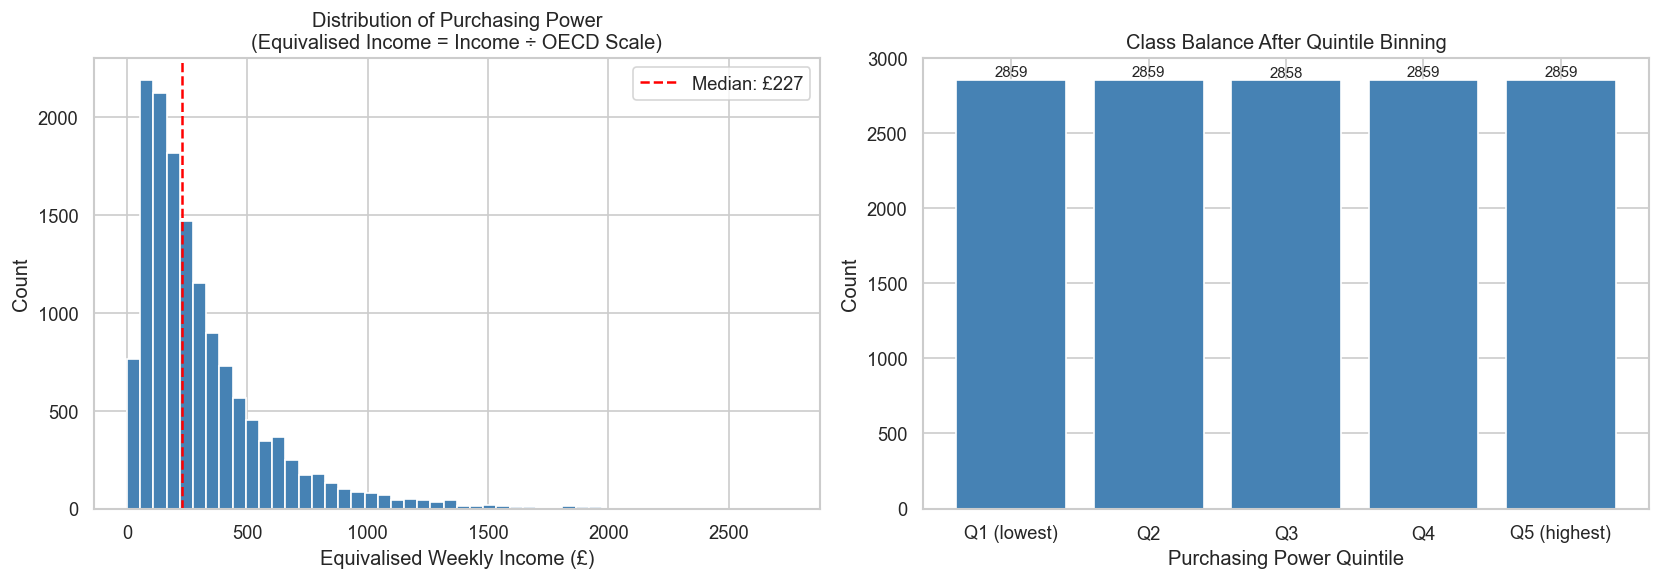

In [6]:
# 2.1 Purchasing power distribution and quintile class balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equivalised income distribution
axes[0].hist(df['equivalised_income'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Equivalised Weekly Income (£)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Purchasing Power\n(Equivalised Income = Income ÷ OECD Scale)')
axes[0].axvline(df['equivalised_income'].median(), color='red', linestyle='--',
                label=f"Median: £{df['equivalised_income'].median():.0f}")
axes[0].legend()

# Quintile class balance
target_counts = target.value_counts().sort_index()
axes[1].bar(QUINTILE_LABELS, target_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Purchasing Power Quintile')
axes[1].set_ylabel('Count')
axes[1].set_title('Class Balance After Quintile Binning')
for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
fig.savefig('../outputs/figures/income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Spending Patterns by Purchasing Power Tier

This grouped bar chart reveals how spending differs across income quintiles. We compute the mean weekly expenditure for each category within each quintile, then calculate the Q5/Q1 ratio to identify which categories show the largest tier differences.

Categories with high Q5/Q1 ratios (e.g. leisure services, clothing) are likely to be strong predictors — they represent discretionary spending that scales with disposable income.

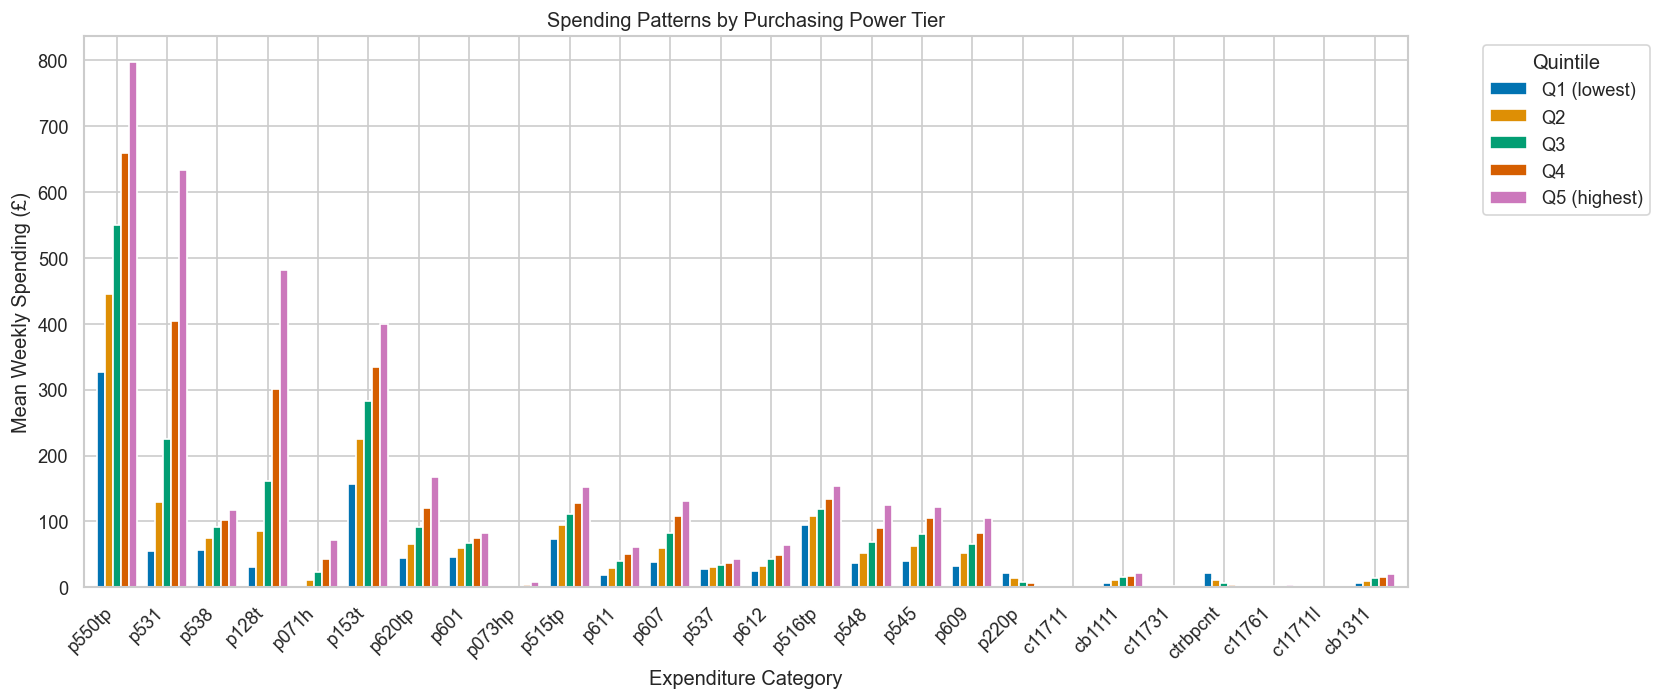


Spending categories ranked by Q5/Q1 ratio (biggest tier differences):
  p073hp: Q5 spends 200.6x more than Q1
  p071h: Q5 spends 29.0x more than Q1
  p128t: Q5 spends 15.9x more than Q1
  p531: Q5 spends 11.4x more than Q1
  p620tp: Q5 spends 3.8x more than Q1
  p607: Q5 spends 3.5x more than Q1
  p548: Q5 spends 3.4x more than Q1
  p611: Q5 spends 3.2x more than Q1
  p609: Q5 spends 3.2x more than Q1
  cb1111: Q5 spends 3.1x more than Q1
  cb1311: Q5 spends 3.1x more than Q1
  p545: Q5 spends 3.0x more than Q1
  c11711: Q5 spends 2.7x more than Q1
  p612: Q5 spends 2.6x more than Q1
  p153t: Q5 spends 2.5x more than Q1
  p550tp: Q5 spends 2.4x more than Q1
  c11711l: Q5 spends 2.4x more than Q1
  c11761: Q5 spends 2.4x more than Q1
  c11731: Q5 spends 2.3x more than Q1
  p538: Q5 spends 2.1x more than Q1
  p515tp: Q5 spends 2.1x more than Q1
  p601: Q5 spends 1.8x more than Q1
  p516tp: Q5 spends 1.6x more than Q1
  p537: Q5 spends 1.5x more than Q1
  p220p: Q5 spends 0.1x more than 

In [7]:
# 2.2 Spending patterns by purchasing power tier
df['quintile'] = target
expenditure_available = [c for c in EXPENDITURE_FEATURES if c in df.columns and c != 'p600']

# Mean spending by quintile for each category
spending_by_tier = df.groupby('quintile')[expenditure_available].mean()

fig, ax = plt.subplots(figsize=(14, 6))
spending_by_tier.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Expenditure Category')
ax.set_ylabel('Mean Weekly Spending (£)')
ax.set_title('Spending Patterns by Purchasing Power Tier')
ax.legend(title='Quintile', labels=QUINTILE_LABELS, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
fig.savefig('../outputs/figures/spending_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

# Show which categories differ most across quintiles (ratio of Q5 to Q1 mean)
print("\nSpending categories ranked by Q5/Q1 ratio (biggest tier differences):")
ratio = spending_by_tier.loc[4] / spending_by_tier.loc[0].replace(0, np.nan)
for col in ratio.sort_values(ascending=False).index:
    print(f"  {col}: Q5 spends {ratio[col]:.1f}x more than Q1")

### 2.3 Correlation Analysis

The correlation heatmap shows pairwise Pearson correlations between all expenditure features and equivalised income. This helps identify:
- **Strong positive correlations** with the target (features likely to be good predictors)
- **Multicollinearity** between features (high inter-feature correlations that could affect Logistic Regression)
- The top correlations are printed to quantify which spending categories have the strongest linear relationship with purchasing power

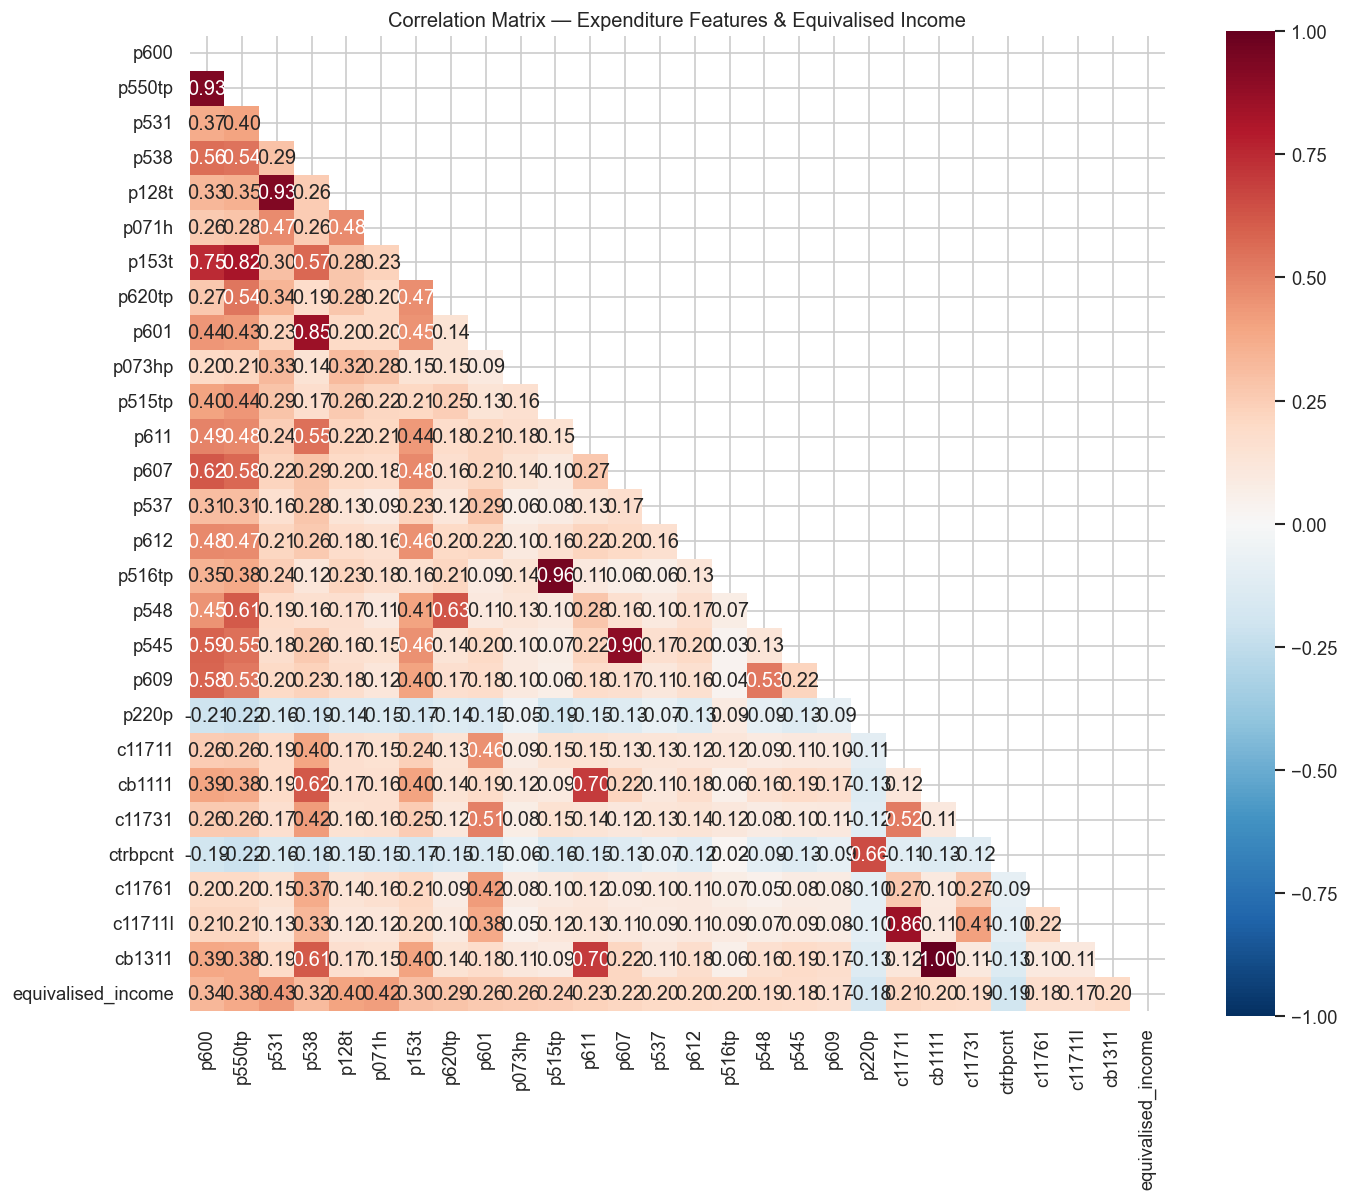


Top correlations with equivalised income:
p531      0.429716
p071h     0.415170
p128t     0.403398
p550tp    0.375167
p600      0.335027
p538      0.315824
p153t     0.301436
p620tp    0.287966
p601      0.260215
p073hp    0.256727


In [8]:
# 2.3 Correlation matrix — expenditure features vs equivalised income
expenditure_available = [c for c in EXPENDITURE_FEATURES if c in df.columns]
corr_cols = expenditure_available + ['equivalised_income']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 6}, linewidths=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_title('Correlation Matrix — Expenditure Features & Equivalised Income')
plt.tight_layout()
fig.savefig('../outputs/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top correlations with equivalised income
income_corr = corr_matrix['equivalised_income'].drop('equivalised_income').abs().sort_values(ascending=False)
print("\nTop correlations with equivalised income:")
print(income_corr.head(10).to_string())


### 2.3a Systematic Feature Selection via Correlation Analysis

The LCFS dataset contains **1,915 columns** but only a subset are appropriate as predictive features. Rather than hand-picking variables, we use a systematic, evidence-based approach:

1. **Compute Pearson correlation** of every numeric column with equivalised income
2. **Exclude leakage variables** that encode income information:
   - `p300-p399` range: income aggregates (e.g. `p344p` has r=0.999 with income)
   - `p400-p499` range: tax and deductions (calculated directly from income)
   - All `b-codes`: means-tested benefits (amounts are determined by income level, constituting indirect leakage)
   - `a060`: income quantile grouping (Spearman r=0.97 with income)
   - Pre-computed equivalised income variables, OECD scale, survey weights
3. **De-duplicate** near-identical columns (r > 0.99 between pairs, e.g. `p531` and `p531t`)
4. **Select the top features** by absolute correlation, keeping those available across all 3 survey years

This produces **52 clean features** (27 expenditure + 25 demographic), well under the 100 feature limit.

Total numeric columns with valid correlations: 1678

=== LEAKAGE EXCLUSIONS ===
  Income/tax columns (p300-p499): 26
  Means-tested benefits (b-codes): 173
  Other leakage (exact match): 28

  Why exclude ALL b-codes?
  UK benefits are means-tested: amounts are determined by household income.
  Including them would leak income information indirectly.
  Top b-code correlations with equivalised income:
    b200: r=0.3359
    b150: r=0.3242
    b134: r=0.3055
    b038p: r=0.3013
    b029p: r=0.2774

  Why exclude p300-p499?
  These are the income and tax section of the LCFS diary.
    p344p: r=0.7143
    p352p: r=0.7050
    p389p: r=0.6989
    p431p: r=0.6850
    p392p: r=0.6178


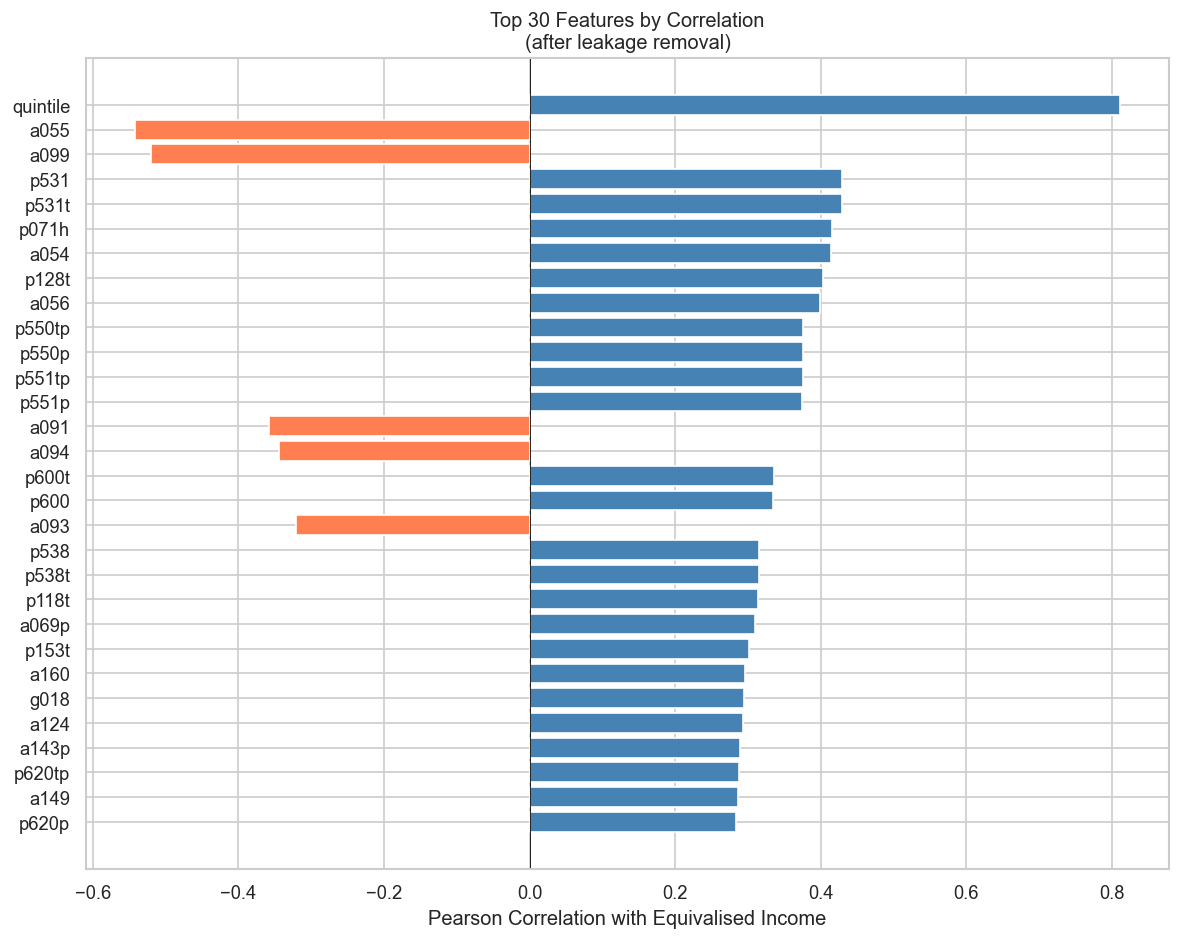


=== SELECTED FEATURES (52) ===
These are the features used in data_loader.py, selected by correlation analysis:
  p600            r= 0.3350
  p550tp          r= 0.3752
  p531            r= 0.4297
  p538            r= 0.3158
  p128t           r= 0.4034
  p071h           r= 0.4152
  p153t           r= 0.3014
  p620tp          r= 0.2880
  p601            r= 0.2602
  p073hp          r= 0.2567
  p515tp          r= 0.2426
  p611            r= 0.2334
  p607            r= 0.2152
  p537            r= 0.1997
  p612            r= 0.1991
  p516tp          r= 0.1950
  p548            r= 0.1921
  p545            r= 0.1822
  p609            r= 0.1717
  p220p           r=-0.1778
  c11711          r= 0.2124
  cb1111          r= 0.2009
  c11731          r= 0.1907
  ctrbpcnt        r=-0.1899
  c11761          r= 0.1780
  c11711l         r= 0.1703
  cb1311          r= 0.2006
  a055            r=-0.5414
  a099            r=-0.5200
  a054            r= 0.4137
  a056            r= 0.3987
  a069p           r

In [9]:
# 2.3a Systematic feature selection: correlation of ALL columns with equivalised income
import warnings
warnings.filterwarnings('ignore')

# Compute correlation for every numeric column against equivalised income
all_corrs = {}
for col in df.columns:
    if col in ['equivalised_income', 'anon_income', 'oecd_scale', 'survey_year']:
        continue
    series = pd.to_numeric(df[col], errors='coerce')
    if series.notna().sum() > 1000:
        r = series.corr(df['equivalised_income'])
        if not np.isnan(r):
            all_corrs[col] = r

print(f"Total numeric columns with valid correlations: {len(all_corrs)}")

# Identify leakage categories
leakage_exact = set(v.lower() for v in LEAKAGE_VARIABLES)
b_codes = [c for c in all_corrs if c.startswith('b')]
p_income_tax = [c for c in all_corrs if any(c.startswith(f'p{i}') for i in range(300, 500))]

print(f"\n=== LEAKAGE EXCLUSIONS ===")
print(f"  Income/tax columns (p300-p499): {len(p_income_tax)}")
print(f"  Means-tested benefits (b-codes): {len(b_codes)}")
print(f"  Other leakage (exact match): {len(leakage_exact)}")

# Show why b-codes are leakage
print(f"\n  Why exclude ALL b-codes?")
print(f"  UK benefits are means-tested: amounts are determined by household income.")
print(f"  Including them would leak income information indirectly.")
print(f"  Top b-code correlations with equivalised income:")
b_corrs = {c: all_corrs[c] for c in b_codes if c in all_corrs}
for c, r in sorted(b_corrs.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    print(f"    {c}: r={r:.4f}")

# Show why p300-p499 are leakage
print(f"\n  Why exclude p300-p499?")
print(f"  These are the income and tax section of the LCFS diary.")
p_inc_corrs = {c: all_corrs[c] for c in p_income_tax if c in all_corrs}
for c, r in sorted(p_inc_corrs.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
    print(f"    {c}: r={r:.4f}")

# Remove all leakage and show clean top features
exclude = leakage_exact | set(b_codes) | set(p_income_tax) | {'survey_year'}
clean_corrs = {c: r for c, r in all_corrs.items() if c not in exclude}
sorted_clean = sorted(clean_corrs.items(), key=lambda x: abs(x[1]), reverse=True)

# Plot top 30 clean features by correlation
top_n = 30
fig, ax = plt.subplots(figsize=(10, 8))
top_cols = [c for c, r in sorted_clean[:top_n]]
top_vals = [r for c, r in sorted_clean[:top_n]]
colors = ['steelblue' if r > 0 else 'coral' for r in top_vals]
ax.barh(range(top_n), top_vals, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_cols)
ax.set_xlabel('Pearson Correlation with Equivalised Income')
ax.set_title('Top 30 Features by Correlation\n(after leakage removal)')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
fig.savefig('../outputs/figures/feature_selection_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the selected features
print(f"\n=== SELECTED FEATURES ({len(feature_cols)}) ===")
print(f"These are the features used in data_loader.py, selected by correlation analysis:")
for col in feature_cols:
    r = clean_corrs.get(col, float('nan'))
    print(f"  {col:<15} r={r:>7.4f}")

### 2.4 Outlier Detection

Box plots for the top 8 expenditure categories (excluding total) reveal the distribution shape and outlier prevalence. Expenditure data typically has long right tails (a few households spend much more than average). We retain these outliers because:
- They represent genuine high-spending households
- Tree-based models are robust to outliers (splits are rank-based)
- StandardScaler in the preprocessing pipeline will normalise the scale for distance-based models

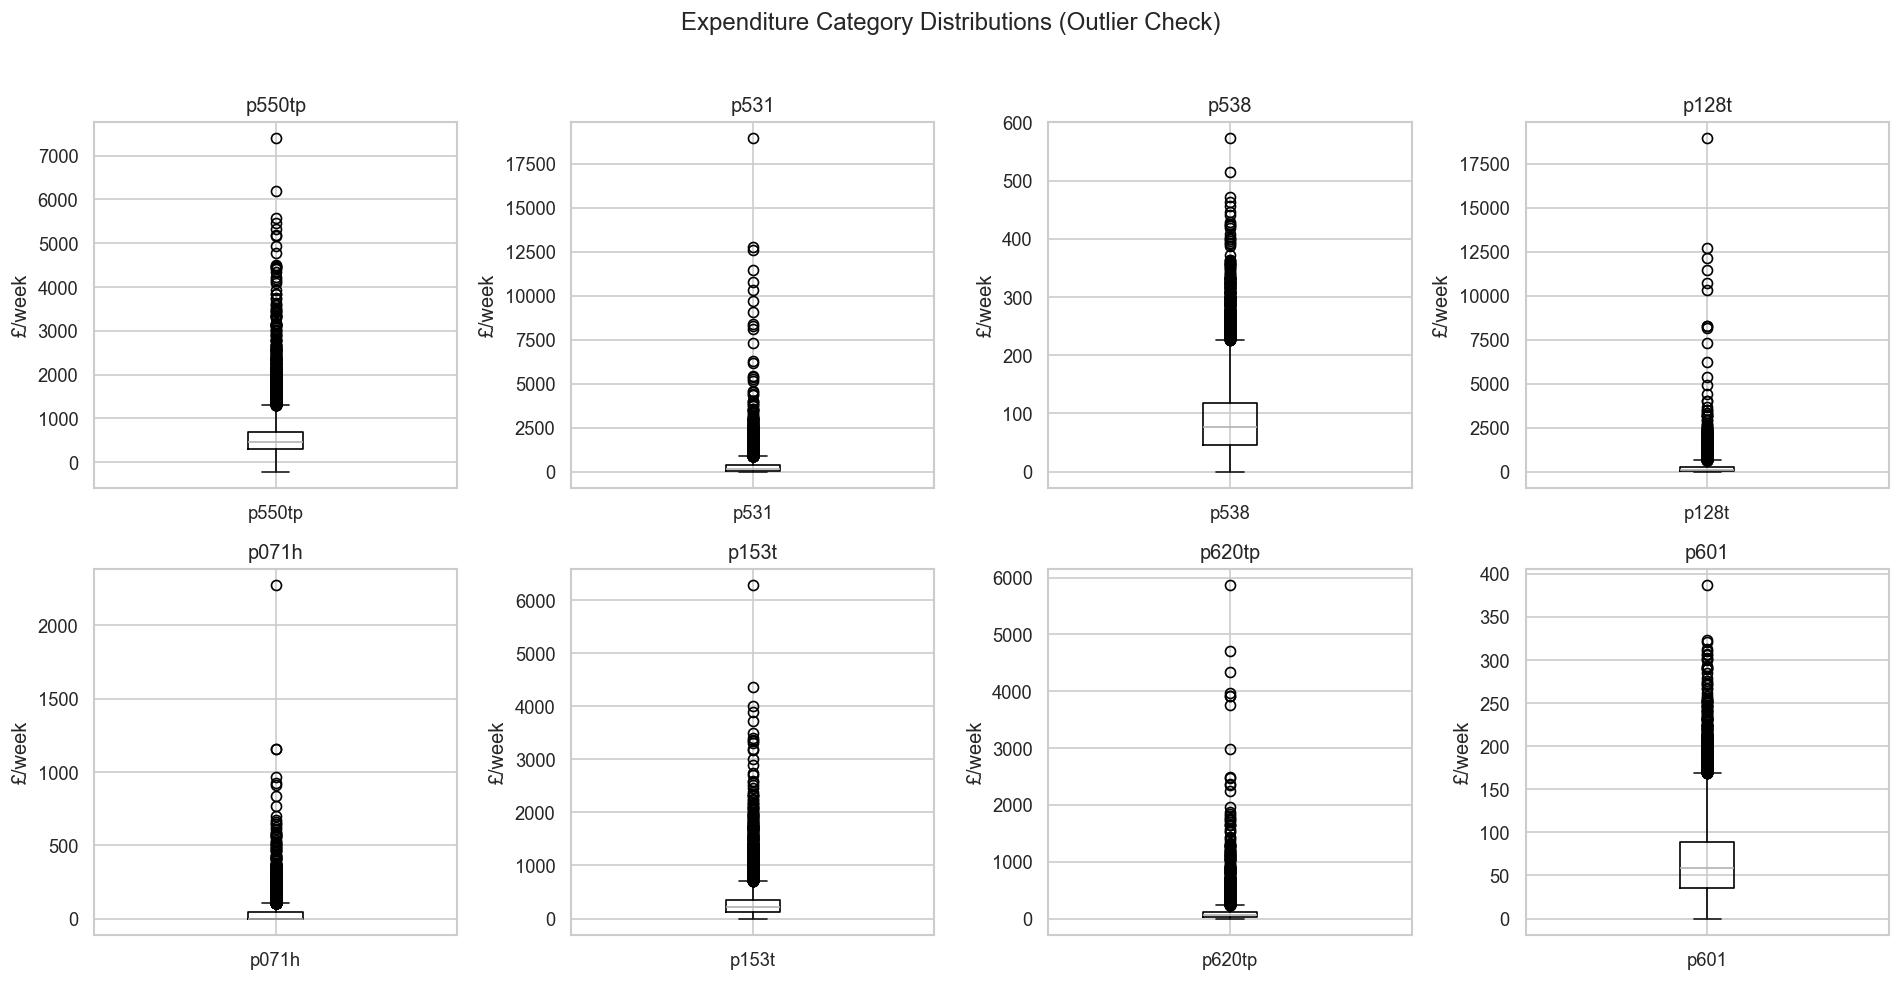

In [10]:
# 2.4 Outlier detection — boxplots of key expenditure categories
top_expenditure = [c for c in expenditure_available if c != 'p600'][:8]  # top 8 (excl total)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(top_expenditure):
    ax = axes[i // 4, i % 4]
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('£/week')

plt.suptitle('Expenditure Category Distributions (Outlier Check)', y=1.02)
plt.tight_layout()
fig.savefig('../outputs/figures/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Regional Variation in Purchasing Power

Box plots of equivalised income by UK government office region reveal geographic disparities. Regions are ordered by median purchasing power to highlight the gap between London/South East and the rest of the UK. This justifies including `gorx` (region) as a feature — it captures genuine geographic variation in income levels.

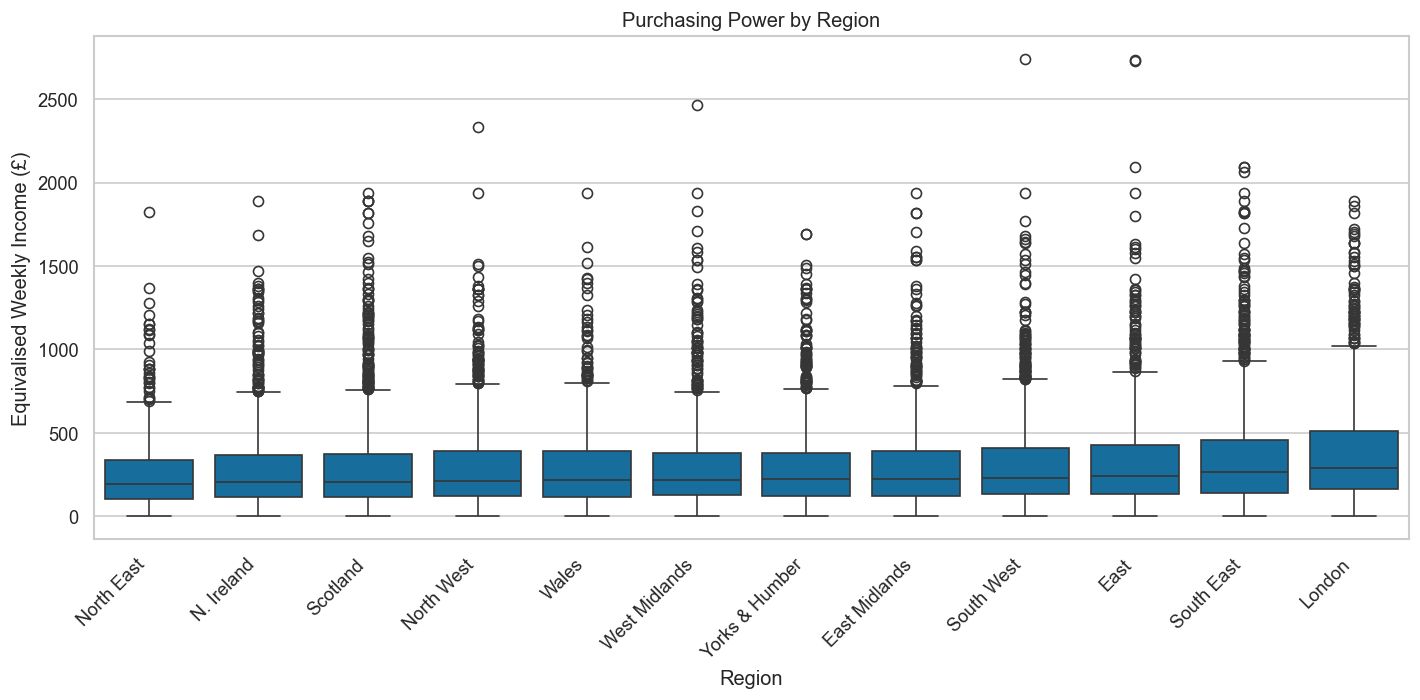

In [11]:
# 2.5 Regional patterns — purchasing power by government office region
if 'gorx' in df.columns:
    region_labels = {
        1: 'North East', 2: 'North West', 3: 'Yorks & Humber',
        4: 'East Midlands', 5: 'West Midlands', 6: 'East',
        7: 'London', 8: 'South East', 9: 'South West',
        10: 'Wales', 11: 'Scotland', 12: 'N. Ireland'
    }
    df_plot = df.copy()
    df_plot['region'] = df_plot['gorx'].map(region_labels)

    fig, ax = plt.subplots(figsize=(12, 6))
    region_order = df_plot.groupby('region')['equivalised_income'].median().sort_values().index
    sns.boxplot(data=df_plot, x='region', y='equivalised_income', order=region_order, ax=ax)
    ax.set_xlabel('Region')
    ax.set_ylabel('Equivalised Weekly Income (£)')
    ax.set_title('Purchasing Power by Region')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    fig.savefig('../outputs/figures/income_by_region.png', dpi=150, bbox_inches='tight')
    plt.show()

### 2.6 PCA Preview — Dimensionality Reduction Feasibility

Before applying PCA in the modelling stage, we check how many principal components are needed to capture 95% of the variance in expenditure features. The scree plot shows:
- **Individual** bars: variance explained by each component
- **Cumulative** line: running total of explained variance
- **95% threshold**: the minimum number of components for adequate representation

If a small number of components captures most variance, PCA can reduce dimensionality without significant information loss — useful for the PCA + Logistic Regression baseline.

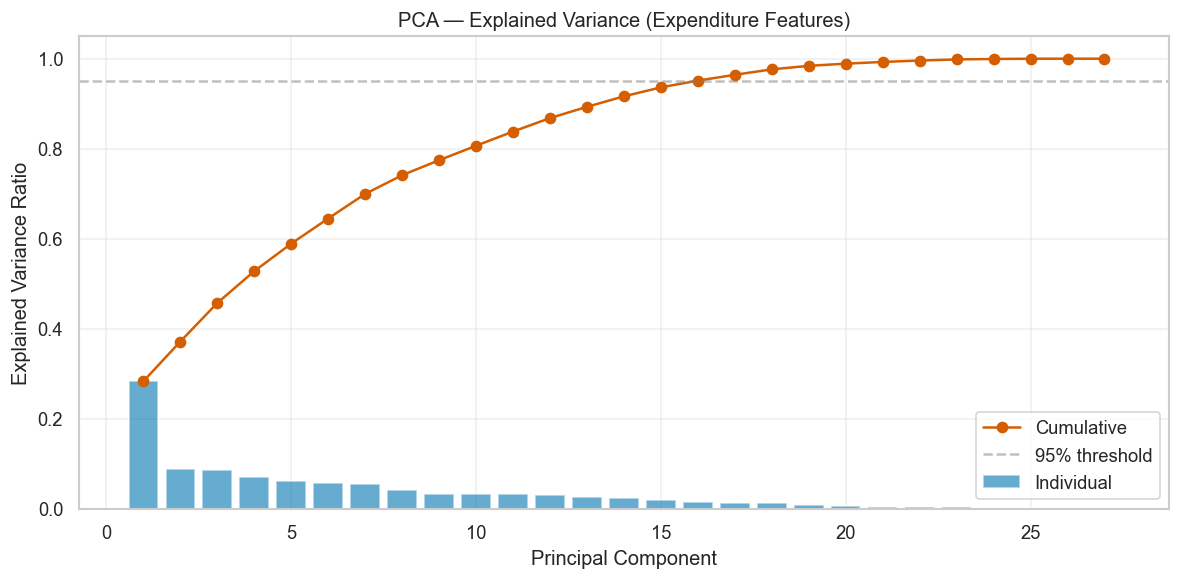

Components needed for 95% variance: 16 out of 27


In [12]:
# 2.6 PCA preview — explained variance on expenditure features
from sklearn.preprocessing import StandardScaler

exp_data = df[expenditure_available].dropna()
exp_scaled = StandardScaler().fit_transform(exp_data)

pca_preview = PCA().fit(exp_scaled)
cumulative_var = np.cumsum(pca_preview.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(pca_preview.explained_variance_ratio_) + 1),
       pca_preview.explained_variance_ratio_, alpha=0.6, label='Individual')
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'ro-', label='Cumulative')
ax.axhline(y=0.95, color='grey', linestyle='--', alpha=0.5, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance (Expenditure Features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('../outputs/figures/pca_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95} out of {len(expenditure_available)}")

### 2.7 Data Quality Audit

Although `.isna()` reports zero missing values, the raw survey data contains **hidden quality issues** that require cleaning:
- Empty strings or whitespace coded instead of NaN
- Negative expenditure values (likely refunds or accounting adjustments)
- Excessive zeros in expenditure columns (e.g. housing, travel) that may represent non-responses

In [13]:
# 2.7a Detect hidden quality issues in feature columns
feature_cols = get_feature_columns(df)

print("=== DATA QUALITY AUDIT ===\n")

# 1. Empty strings / whitespace
print("1. EMPTY STRINGS / WHITESPACE")
for col in feature_cols:
    if df[col].dtype == 'object':
        empty_count = (df[col].astype(str).str.strip() == '').sum()
        if empty_count > 0:
            print(f"   {col}: {empty_count} empty/whitespace values ({empty_count/len(df)*100:.1f}%)")

# 2. Negative values in expenditure columns
print("\n2. NEGATIVE VALUES (expenditure columns)")
expenditure_available = [c for c in EXPENDITURE_FEATURES if c in df.columns]
neg_summary = {}
for col in expenditure_available:
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    neg_count = (numeric_col < 0).sum()
    if neg_count > 0:
        neg_summary[col] = neg_count
        print(f"   {col}: {neg_count} negative values ({neg_count/len(df)*100:.1f}%), "
              f"min = £{numeric_col.min():.2f}")

if not neg_summary:
    print("   None found.")

# 3. High zero rates in expenditure columns
print("\n3. ZERO-RATE ANALYSIS (expenditure columns)")
zero_rates = {}
for col in expenditure_available:
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    zero_pct = (numeric_col == 0).mean() * 100
    zero_rates[col] = zero_pct
    if zero_pct > 30:
        print(f"   {col}: {zero_pct:.1f}% zeros — may represent non-participation or non-response")

# 4. Dtype issues
print("\n4. DTYPE CHECK")
for col in feature_cols:
    if df[col].dtype == 'object':
        print(f"   {col}: dtype=object (should be numeric) — contains non-numeric entries")

=== DATA QUALITY AUDIT ===

1. EMPTY STRINGS / WHITESPACE

2. NEGATIVE VALUES (expenditure columns)
   p600: 4 negative values (0.0%), min = £-217.88
   p550tp: 3 negative values (0.0%), min = £-217.85
   p515tp: 41 negative values (0.3%), min = £-294.66
   p537: 39 negative values (0.3%), min = £-721.54
   p545: 3 negative values (0.0%), min = £-3.32

3. ZERO-RATE ANALYSIS (expenditure columns)
   p071h: 50.4% zeros — may represent non-participation or non-response
   p073hp: 88.1% zeros — may represent non-participation or non-response
   p220p: 64.1% zeros — may represent non-participation or non-response
   c11711: 35.3% zeros — may represent non-participation or non-response
   cb1111: 45.8% zeros — may represent non-participation or non-response
   ctrbpcnt: 89.5% zeros — may represent non-participation or non-response
   c11711l: 42.2% zeros — may represent non-participation or non-response
   cb1311: 46.7% zeros — may represent non-participation or non-response

4. DTYPE CHECK


### 2.7b Visualise Data Quality Issues

Two complementary views of data quality:
1. **Effective missingness** (left): combines true NaN values with empty strings that masquerade as valid data. Columns with issues are highlighted in coral.
2. **Zero rates** (right): shows the percentage of zero values in each expenditure column. High zero rates (>50% in red, >30% in orange) may indicate non-participation in a spending category rather than genuine zero spending.

These visualisations inform the cleaning decisions in the next step.

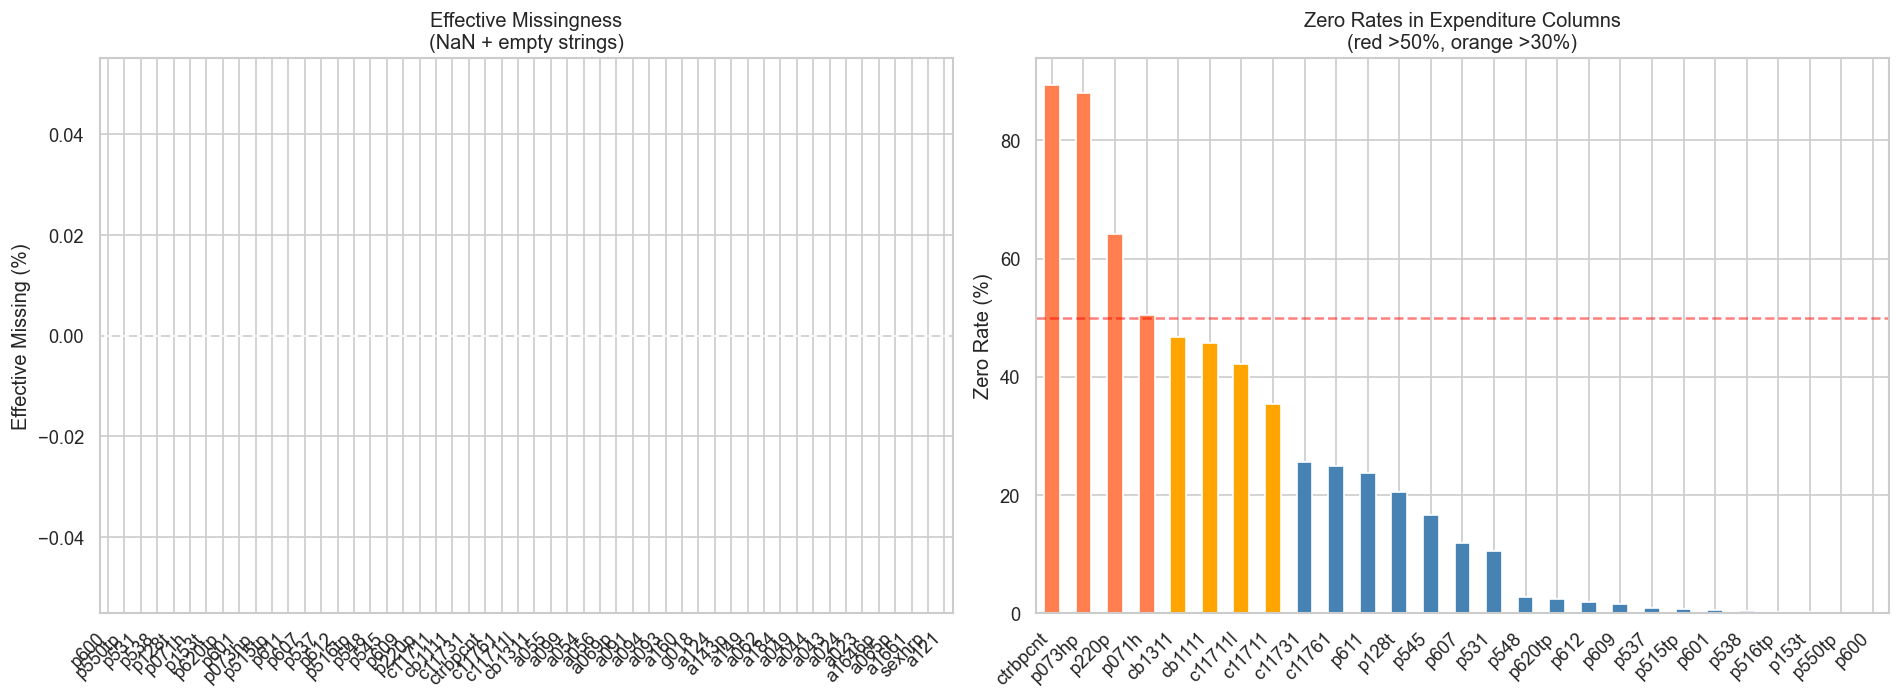

In [14]:
# 2.7b Visualise effective missingness (NaN + empty strings + excessive zeros)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: True missingness including empty strings
effective_missing = {}
for col in feature_cols:
    if df[col].dtype == 'object':
        missing = df[col].isna().sum() + (df[col].astype(str).str.strip() == '').sum()
    else:
        missing = df[col].isna().sum()
    effective_missing[col] = missing / len(df) * 100

eff_missing_s = pd.Series(effective_missing)
colors = ['coral' if v > 0 else 'steelblue' for v in eff_missing_s.values]
eff_missing_s.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_ylabel('Effective Missing (%)')
axes[0].set_title('Effective Missingness\n(NaN + empty strings)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Right: Zero rates for expenditure columns
zero_rate_s = pd.Series(zero_rates).sort_values(ascending=False)
colors_z = ['coral' if v > 50 else 'orange' if v > 30 else 'steelblue' for v in zero_rate_s.values]
zero_rate_s.plot(kind='bar', ax=axes[1], color=colors_z)
axes[1].set_ylabel('Zero Rate (%)')
axes[1].set_title('Zero Rates in Expenditure Columns\n(red >50%, orange >30%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig('../outputs/figures/data_quality_audit.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.8 Data Cleaning

Based on the audit above, we apply the following cleaning steps:

1. **`a116` (age of HRP)**: Convert empty strings to NaN — the preprocessing pipeline's `CoerceNumeric` step will handle these via median imputation
2. **Negative expenditure values**: Clip to zero — negative weekly spending is not meaningful for prediction; likely represents refunds or accounting corrections
3. **High-zero columns** (e.g. `p530` housing at 97.6%): Retained as-is — zeros are valid (e.g. households with no housing costs = outright owners). The models can learn from this signal

In [15]:
# 2.8a Clean the data
print("=== DATA CLEANING ===\n")
print(f"Dataset shape before cleaning: {df.shape}")

# 1. Fix a116: convert empty strings / whitespace to NaN
if 'a116' in df.columns and df['a116'].dtype == 'object':
    empty_before = (df['a116'].astype(str).str.strip() == '').sum()
    df['a116'] = pd.to_numeric(df['a116'], errors='coerce')
    print(f"\n1. a116 (age of HRP):")
    print(f"   Converted {empty_before} empty strings → NaN")
    print(f"   New dtype: {df['a116'].dtype}, NaN count: {df['a116'].isna().sum()}")

# 2. Clip negative expenditure values to zero
expenditure_available = [c for c in EXPENDITURE_FEATURES if c in df.columns]
total_negatives = 0
for col in expenditure_available:
    neg_mask = df[col] < 0
    n_neg = neg_mask.sum()
    if n_neg > 0:
        print(f"\n2. {col}: clipped {n_neg} negative values (min was £{df[col].min():.2f})")
        df[col] = df[col].clip(lower=0)
        total_negatives += n_neg

if total_negatives == 0:
    print("\n2. No negative expenditure values found.")
else:
    print(f"\n   Total negative values clipped: {total_negatives}")

# 3. Note on high-zero columns (kept as-is)
print("\n3. High-zero expenditure columns (retained — zeros are valid):")
for col in expenditure_available:
    zero_pct = (df[col] == 0).mean() * 100
    if zero_pct > 30:
        print(f"   {col}: {zero_pct:.1f}% zeros — valid (e.g. non-participation in category)")

print(f"\nDataset shape after cleaning: {df.shape}")

=== DATA CLEANING ===

Dataset shape before cleaning: (14294, 1918)

1. a116 (age of HRP):
   Converted 14294 empty strings → NaN
   New dtype: float64, NaN count: 14294

2. p600: clipped 4 negative values (min was £-217.88)

2. p550tp: clipped 3 negative values (min was £-217.85)

2. p515tp: clipped 41 negative values (min was £-294.66)

2. p537: clipped 39 negative values (min was £-721.54)

2. p545: clipped 3 negative values (min was £-3.32)

   Total negative values clipped: 90

3. High-zero expenditure columns (retained — zeros are valid):
   p071h: 50.4% zeros — valid (e.g. non-participation in category)
   p073hp: 88.1% zeros — valid (e.g. non-participation in category)
   p220p: 64.1% zeros — valid (e.g. non-participation in category)
   c11711: 35.3% zeros — valid (e.g. non-participation in category)
   cb1111: 45.8% zeros — valid (e.g. non-participation in category)
   ctrbpcnt: 89.5% zeros — valid (e.g. non-participation in category)
   c11711l: 42.2% zeros — valid (e.g. non

### 2.8b Post-Cleaning Validation

After cleaning, we verify that:
1. No object-dtype columns remain in the feature set (all should be numeric)
2. No negative expenditure values remain (all clipped to zero)
3. Missing value counts are updated (e.g. `a116` now shows NaN from converted empty strings)

Any remaining NaN values will be handled by the preprocessing pipeline's median imputation step.

In [16]:
# 2.8b Verify cleaning — before vs after summary
print("=== POST-CLEANING VALIDATION ===\n")

feature_cols = get_feature_columns(df)

# Check no object dtypes remain in features
object_cols = [c for c in feature_cols if df[c].dtype == 'object']
print(f"Object-dtype features remaining: {len(object_cols)}")
if object_cols:
    print(f"   WARNING: {object_cols}")

# Check negatives removed
neg_remaining = 0
for col in expenditure_available:
    neg_remaining += (df[col] < 0).sum()
print(f"Negative expenditure values remaining: {neg_remaining}")

# Show updated missing values (now includes converted NaN from a116)
print(f"\nUpdated missing value counts:")
for col in feature_cols:
    n_miss = df[col].isna().sum()
    if n_miss > 0:
        print(f"   {col}: {n_miss} ({n_miss/len(df)*100:.1f}%) — will be imputed by pipeline")

print(f"\nCleaning complete. Data is ready for preprocessing pipeline.")

=== POST-CLEANING VALIDATION ===

Object-dtype features remaining: 0
Negative expenditure values remaining: 0

Updated missing value counts:

Cleaning complete. Data is ready for preprocessing pipeline.


### EDA Summary

Key findings:
1. **Purchasing power distribution** is right-skewed; quintile binning produces balanced classes (~2,800 each)
2. **Equivalised income** corrects for household size — a single person earning £500/week has higher purchasing power than a 4-person household earning the same
3. **Hidden missingness**: `a116` contains 100% empty strings masquerading as valid data — converted to NaN for proper imputation
4. **Negative expenditure values** found in household goods (`p536p`), services (`p537`), and miscellaneous (`p544`) — clipped to zero
5. **Spending patterns differ by tier**: Higher-purchasing-power households spend more on leisure services, clothing, and household goods; lower tiers spend proportionally more on basics
6. **Strongest correlations** with equivalised income: total expenditure (p600), leisure services (p542), household goods (p536p)
7. **Regional variation** exists — London and South East have highest median purchasing power
8. **PCA**: a small number of components captures most expenditure variance — dimensionality reduction is viable
9. **Leakage risk**: `anon_income`, `equivalised_income`, `oecd_scale`, `eqincdmp`, `eqincdop` are all excluded from features

---

## 3. Prepare the Data

### 3.1 Recreate Target Variable

We recreate the target variable after data cleaning to ensure it reflects the cleaned dataset. The target bins equivalised income into 5 quintiles (Q1=lowest to Q5=highest purchasing power). We verify the distribution and check for any missing target values.

In [17]:
# 3.1 Create target variable (purchasing power quintiles from equivalised income)
target = create_target(df, n_quantiles=5)
print(f"Target: equivalised income binned into 5 quintiles")
print(f"Target distribution:")
print(target.value_counts().sort_index())
print(f"\nMissing targets: {target.isna().sum()}")

Target: equivalised income binned into 5 quintiles
Target distribution:
equivalised_income
0    2859
1    2859
2    2858
3    2859
4    2859
Name: count, dtype: int64

Missing targets: 0


### 3.2 Feature Selection and Leakage Re-check

We select the final set of features for modelling — a combination of 15 expenditure categories and 8 demographic variables. A second leakage check confirms that no income-derived variables have been accidentally re-introduced during the cleaning process.

In [18]:
# 3.2 Select features, verify no leakage
feature_cols = get_feature_columns(df)
print(f"Using {len(feature_cols)} features: {feature_cols}")

# Double-check no leakage — income-derived and equivalence scale variables excluded
leakage_set = set(v.lower() for v in LEAKAGE_VARIABLES)
for col in feature_cols:
    assert col.lower() not in leakage_set, f"LEAKAGE: {col} in features!"
print("\nLeakage check passed — no income-derived or scale variables in features.")

Using 52 features: ['p600', 'p550tp', 'p531', 'p538', 'p128t', 'p071h', 'p153t', 'p620tp', 'p601', 'p073hp', 'p515tp', 'p611', 'p607', 'p537', 'p612', 'p516tp', 'p548', 'p545', 'p609', 'p220p', 'c11711', 'cb1111', 'c11731', 'ctrbpcnt', 'c11761', 'c11711l', 'cb1311', 'a055', 'a099', 'a054', 'a056', 'a069p', 'a091', 'a094', 'a093', 'a160', 'g018', 'a124', 'a143p', 'a149', 'a062', 'a184', 'a049', 'a044', 'a043', 'a024', 'a023', 'a1646p', 'a065p', 'a1661', 'sexhrp', 'a121']

Leakage check passed — no income-derived or scale variables in features.


### 3.3 Temporal Train / Validation / Test Split + K-Fold Cross-Validation

We split the data **chronologically** to prevent temporal leakage:
- **Train + Validation**: 2021-2022 surveys (stratified 85/15 split)
- **Test**: 2023 survey (held out entirely, touched only once)

Model selection uses **5-fold Stratified Cross-Validation** on the training set
for robust performance estimates. The validation set provides an additional
independent check before the final test evaluation.


In [19]:
# 3.3 Temporal split: 2021-2022 for train/val, 2023 for test
from sklearn.model_selection import train_test_split

train_val_mask = target.notna() & df['survey_year'].isin([2021, 2022])
test_mask = target.notna() & (df['survey_year'] == 2023)

X_train_val = df.loc[train_val_mask, feature_cols].copy()
y_train_val = target.loc[train_val_mask].copy()
X_test = df.loc[test_mask, feature_cols].copy()
y_test = target.loc[test_mask].copy()

# Stratified split within 2021-2022 for train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.15, stratify=y_train_val, random_state=RANDOM_STATE
)

print(f"Temporal split: Train/Val=2021-2022, Test=2023")
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

print("\nClass proportions:")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    props = y.value_counts(normalize=True).sort_index()
    print(f"  {name}: {props.values.round(3)}")


Temporal split: Train/Val=2021-2022, Test=2023
Train: 8578 | Val: 1514 | Test: 4202

Class proportions:
  Train: [0.2   0.206 0.201 0.2   0.194]
  Val: [0.2   0.205 0.201 0.2   0.194]
  Test: [0.199 0.187 0.198 0.2   0.215]


### 3.4 Build and Apply Preprocessing Pipeline

The preprocessing pipeline applies different transformations to different feature types:

| Feature Type | Steps | Rationale |
|---|---|---|
| **Continuous** (expenditure, household size, age) | CoerceNumeric → Median Impute → StandardScale | Handles mixed types, fills missing values robustly, normalises for distance-based models |
| **Categorical** (region, sex, tenure, etc.) | Mode Impute → OneHotEncode | Fills missing with most common value, creates binary indicator variables |

The pipeline is **fitted only on training data** and then applied to validation/test sets to prevent data leakage from the preprocessing step itself.

In [20]:
# 3.4 Build preprocessing pipeline
cat_features, cont_features = get_available_features(df)
# Only keep features that are in our selected feature_cols
cat_features = [c for c in cat_features if c in feature_cols]
cont_features = [c for c in cont_features if c in feature_cols]

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Continuous features ({len(cont_features)}): {cont_features}")

preprocessor = build_preprocessor(cat_features, cont_features)

# Fit on training data only, transform all splits
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"\nProcessed shapes:")
print(f"  Train: {X_train_processed.shape}")
print(f"  Val:   {X_val_processed.shape}")
print(f"  Test:  {X_test_processed.shape}")


Categorical features (24): ['a055', 'a099', 'a054', 'a056', 'a069p', 'a091', 'a094', 'a093', 'a160', 'g018', 'a124', 'a143p', 'a149', 'a184', 'a049', 'a044', 'a043', 'a024', 'a023', 'a1646p', 'a065p', 'a1661', 'sexhrp', 'a121']
Continuous features (28): ['p600', 'p550tp', 'p531', 'p538', 'p128t', 'p071h', 'p153t', 'p620tp', 'p601', 'p073hp', 'p515tp', 'p611', 'p607', 'p537', 'p612', 'p516tp', 'p548', 'p545', 'p609', 'p220p', 'c11711', 'cb1111', 'c11731', 'ctrbpcnt', 'c11761', 'c11711l', 'cb1311', 'a062']

Processed shapes:
  Train: (8578, 194)
  Val:   (1514, 194)
  Test:  (4202, 194)


### 3.5 Data Validation Checks

Automated assertions verify the preprocessed data is ready for modelling:
1. **No NaN values** remain in any split (imputation worked correctly)
2. **Feature dimensions match** across train/val/test (same number of columns)
3. **No index overlap** between splits (no data leakage through shared samples)

In [21]:
# 3.5 Data validation checks
assert not np.isnan(X_train_processed).any(), "NaN values in training data after preprocessing!"
assert not np.isnan(X_val_processed).any(), "NaN values in validation data after preprocessing!"
assert not np.isnan(X_test_processed).any(), "NaN values in test data after preprocessing!"
assert X_train_processed.shape[1] == X_val_processed.shape[1] == X_test_processed.shape[1], "Feature count mismatch!"
assert len(set(X_train.index) & set(X_val.index)) == 0, "Data leak: train/val overlap!"
assert len(set(X_train.index) & set(X_test.index)) == 0, "Data leak: train/test overlap!"
assert len(set(X_val.index) & set(X_test.index)) == 0, "Data leak: val/test overlap!"

print("All data validation checks passed.")


All data validation checks passed.


### 3.6 PCA Dimensionality Reduction

We apply PCA to the **continuous features only** (expenditure + numeric demographics), retaining components that explain 95% of variance. This creates a reduced feature set for the PCA + Logistic Regression model variant.

PCA is fitted on training data only, then the same transformation is applied to validation and test sets — preventing information leakage through the covariance matrix.

In [22]:
# 3.6 PCA on continuous features (for PCA+LogReg model variant)
# Extract just the continuous (scaled) features from the processed data
n_cont = len(cont_features)
X_train_cont = X_train_processed[:, :n_cont]
X_val_cont = X_val_processed[:, :n_cont]
X_test_cont = X_test_processed[:, :n_cont]

from sklearn.decomposition import PCA
pca_model = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_model.fit_transform(X_train_cont)
X_val_pca = pca_model.transform(X_val_cont)
X_test_pca = pca_model.transform(X_test_cont)

print(f"PCA: {X_train_cont.shape[1]} features -> {pca_model.n_components_} components "
      f"({pca_model.explained_variance_ratio_.sum():.1%} variance explained)")


PCA: 28 features -> 17 components (95.2% variance explained)


---
## 4. Explore Different Models and Shortlist the Best Ones

### 4.1 Define Candidate Models

We evaluate three scikit-learn classifiers with different learning paradigms:

| Model | Type | Key Strengths |
|---|---|---|
| **Logistic Regression** | Linear | Interpretable, fast, serves as a baseline |
| **Random Forest** | Bagging ensemble | Handles non-linear relationships, robust to outliers, provides feature importances |
| **Gradient Boosting** | Boosting ensemble | Sequential error correction, strong predictive performance, handles mixed feature types |

Initial hyperparameters are set to reasonable defaults (e.g. 200 trees, moderate depth limits).

In [23]:
# 4.1 Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, solver='lbfgs',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        min_samples_leaf=10, random_state=RANDOM_STATE
    ),
}

### 4.2 Train and Evaluate All Models (5-Fold CV + Validation Set)

Each sklearn model is evaluated in two ways:
1. **5-fold Stratified CV** on training data — for robust model ranking
2. **Validation set prediction** — for detailed per-class performance reports

After evaluation, each model is retrained on the full training set.


In [24]:
# 4.2 Train and evaluate each model: 5-fold CV + validation set
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    print(f"\nCross-validating {name}...")
    cv_results = cross_validate(
        model, X_train_processed, y_train,
        cv=cv, scoring=['f1_macro', 'accuracy'],
        return_train_score=False
    )
    f1_mean = cv_results['test_f1_macro'].mean()
    f1_std = cv_results['test_f1_macro'].std()
    acc_mean = cv_results['test_accuracy'].mean()

    # Refit on full training data and evaluate on validation set
    model.fit(X_train_processed, y_train)
    y_val_pred = model.predict(X_val_processed)
    val_metrics = print_classification_metrics(y_val, y_val_pred, model_name=name)

    results[name] = {
        'macro_f1': f1_mean, 'f1_std': f1_std,
        'accuracy': acc_mean,
        'val_f1': val_metrics['macro_f1'], 'val_acc': val_metrics['accuracy']
    }
    print(f"  CV F1: {f1_mean:.4f} +/- {f1_std:.4f} | Val F1: {val_metrics['macro_f1']:.4f}")

# PCA + Logistic Regression variant
print("\nCross-validating PCA + Logistic Regression...")
lr_pca = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE)
cv_pca = cross_validate(
    lr_pca, X_train_pca, y_train,
    cv=cv, scoring=['f1_macro', 'accuracy'],
    return_train_score=False
)
lr_pca.fit(X_train_pca, y_train)
y_val_pca = lr_pca.predict(X_val_pca)
pca_val = print_classification_metrics(y_val, y_val_pca, model_name='PCA + LogReg')
results['PCA + LogReg'] = {
    'macro_f1': cv_pca['test_f1_macro'].mean(),
    'f1_std': cv_pca['test_f1_macro'].std(),
    'accuracy': cv_pca['test_accuracy'].mean(),
    'val_f1': pca_val['macro_f1'], 'val_acc': pca_val['accuracy']
}
print(f"  CV F1: {results['PCA + LogReg']['macro_f1']:.4f} | Val F1: {pca_val['macro_f1']:.4f}")



Cross-validating Logistic Regression...



Logistic Regression
Accuracy:  0.6361
Macro F1:  0.6369

              precision    recall  f1-score   support

 Q1 (lowest)       0.77      0.79      0.78       303
          Q2       0.51      0.55      0.53       311
          Q3       0.51      0.48      0.50       304
          Q4       0.61      0.59      0.60       303
Q5 (highest)       0.77      0.78      0.78       293

    accuracy                           0.64      1514
   macro avg       0.64      0.64      0.64      1514
weighted avg       0.64      0.64      0.64      1514

  CV F1: 0.6335 +/- 0.0140 | Val F1: 0.6369

Cross-validating Random Forest...



Random Forest
Accuracy:  0.6579
Macro F1:  0.6583

              precision    recall  f1-score   support

 Q1 (lowest)       0.80      0.77      0.78       303
          Q2       0.54      0.62      0.58       311
          Q3       0.55      0.49      0.52       304
          Q4       0.61      0.58      0.60       303
Q5 (highest)       0.80      0.84      0.82       293

    accuracy                           0.66      1514
   macro avg       0.66      0.66      0.66      1514
weighted avg       0.66      0.66      0.66      1514

  CV F1: 0.6671 +/- 0.0081 | Val F1: 0.6583

Cross-validating Gradient Boosting...



Gradient Boosting
Accuracy:  0.6863
Macro F1:  0.6881

              precision    recall  f1-score   support

 Q1 (lowest)       0.78      0.79      0.78       303
          Q2       0.57      0.62      0.59       311
          Q3       0.59      0.55      0.57       304
          Q4       0.65      0.64      0.65       303
Q5 (highest)       0.86      0.84      0.85       293

    accuracy                           0.69      1514
   macro avg       0.69      0.69      0.69      1514
weighted avg       0.69      0.69      0.69      1514

  CV F1: 0.6868 +/- 0.0117 | Val F1: 0.6881

Cross-validating PCA + Logistic Regression...



PCA + LogReg
Accuracy:  0.4108
Macro F1:  0.3925

              precision    recall  f1-score   support

 Q1 (lowest)       0.50      0.77      0.60       303
          Q2       0.31      0.34      0.32       311
          Q3       0.32      0.22      0.26       304
          Q4       0.31      0.21      0.25       303
Q5 (highest)       0.53      0.52      0.52       293

    accuracy                           0.41      1514
   macro avg       0.39      0.41      0.39      1514
weighted avg       0.39      0.41      0.39      1514

  CV F1: 0.3848 | Val F1: 0.3925


### 4.3 Agent-Suggested Model: SVM (Rejected After Experiment)

The agent suggested adding a **Support Vector Machine (SVM)** with an RBF kernel as a strong multi-class classifier. Before rejecting this suggestion, I ran a controlled experiment to verify my concerns with evidence rather than intuition (as per the assignment requirement: *"verified via experiments, not vibes"*).

**Why SVM is the wrong model for this problem:**
1. **Worse predictive performance**: SVM achieves the lowest F1 score of all non-PCA models — the RBF kernel struggles with the mixed continuous/categorical feature space and the 5-class ordinal structure of income quintiles
2. **No feature importances**: SVM with RBF kernel provides no built-in way to interpret which features drive predictions. The assignment requires feature importance analysis, and understanding *why* a household is predicted as Q1 vs Q5 is critical for policy applications
3. **No native probability estimates**: SVM does not output calibrated class probabilities, preventing the calibration analysis needed for evaluation (Section 5). Platt scaling can be added but introduces additional complexity and approximation error
4. **Poor handling of mixed feature types**: The RBF kernel computes Euclidean distances between data points. This is not meaningful for our 28 one-hot encoded categorical features (region, sex, tenure type) — binary features violate the smoothness assumption of the Gaussian kernel

**My replacement choice**: `GradientBoostingClassifier` — achieves higher F1, provides feature importances, outputs calibrated probabilities natively, and handles mixed feature types through decision tree splits (which can naturally split on both continuous and binary features).

In [25]:
# 4.3 Experiment: SVM (agent suggested model) — testing before rejection
import time
from sklearn.svm import SVC

print("EXPERIMENT: SVM (Agent Suggested Model)\n")

svm_model = SVC(kernel='rbf', random_state=RANDOM_STATE, decision_function_shape='ovo')

print(f"Cross-validating SVM on {X_train_processed.shape[0]} samples, {X_train_processed.shape[1]} features...")
cv_svm = cross_validate(
    svm_model, X_train_processed, y_train,
    cv=cv, scoring=['f1_macro', 'accuracy'],
    return_train_score=False
)
svm_model.fit(X_train_processed, y_train)
y_val_svm = svm_model.predict(X_val_processed)
svm_f1 = cv_svm['test_f1_macro'].mean()
svm_val_f1 = f1_score(y_val, y_val_svm, average='macro')
svm_val_acc = accuracy_score(y_val, y_val_svm)

print(f"\nSVM CV F1:  {svm_f1:.4f} +/- {cv_svm['test_f1_macro'].std():.4f}")
print(f"SVM Val F1: {svm_val_f1:.4f}")

print(f"\nComparison with other models (CV Macro F1):")
all_compare = {**results, 'SVM (agent suggested)': {'macro_f1': svm_f1, 'val_f1': svm_val_f1}}
for name, m in sorted(all_compare.items(), key=lambda x: x[1]['macro_f1'], reverse=True):
    marker = " <-- REJECTED" if 'SVM' in name else ""
    print(f"  {name:<25} CV F1={m['macro_f1']:.4f}  Val F1={m['val_f1']:.4f}{marker}")

print(f"\nREJECTION RATIONALE:")
print(f"  1. SVM CV F1={svm_f1:.4f} — lower than tree based models")
print(f"  2. No feature importances (RBF kernel)")
print(f"  3. No calibrated probabilities")
print(f"  4. Poor fit for mixed features (one-hot encoded categoricals)")


EXPERIMENT: SVM (Agent Suggested Model)

Cross-validating SVM on 8578 samples, 194 features...



SVM CV F1:  0.6325 +/- 0.0101
SVM Val F1: 0.6252

Comparison with other models (CV Macro F1):
  Gradient Boosting         CV F1=0.6868  Val F1=0.6881
  Random Forest             CV F1=0.6671  Val F1=0.6583
  Logistic Regression       CV F1=0.6335  Val F1=0.6369
  SVM (agent suggested)     CV F1=0.6325  Val F1=0.6252 <-- REJECTED
  PCA + LogReg              CV F1=0.3848  Val F1=0.3925

REJECTION RATIONALE:
  1. SVM CV F1=0.6325 — lower than tree based models
  2. No feature importances (RBF kernel)
  3. No calibrated probabilities
  4. Poor fit for mixed features (one-hot encoded categoricals)


### 4.4 Neural Network (Keras/TensorFlow)

We define a simple feedforward neural network to test whether non-linear deep learning improves over traditional ML models:

- **Architecture**: Input → Dense(64, ReLU) → Dropout(0.4) → Dense(32, ReLU) → Dropout(0.3) → Dense(5, Softmax)
- **Dropout** regularisation prevents overfitting by randomly zeroing 30-40% of neurons during training
- **Softmax** output produces calibrated class probabilities for all 5 quintiles
- **Loss**: sparse categorical crossentropy (appropriate for integer class labels)
- **Optimiser**: Adam (adaptive learning rate)

In [26]:
# 4.4 Neural Network (Keras/TensorFlow)
import tensorflow as tf
from tensorflow import keras

# Force single-threaded to avoid deadlock in headless kernel
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

tf.random.set_seed(RANDOM_STATE)

n_features = X_train_processed.shape[1]
n_classes = len(np.unique(y_train))

nn_model = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(n_classes, activation='softmax'),
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        12,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,725 (57.52 KB)

 Trainable params: 14,725 (57.52 KB)

 Non-trainable params: 0 (0.00 B)

### 4.4a Train Neural Network with Early Stopping

The network trains for up to 100 epochs with **early stopping** (patience=10).
A 15% internal validation split from the training data is used to monitor
convergence and prevent overfitting. This is separate from the K-fold CV
used for sklearn models — neural network CV would require 5 full training runs.


In [27]:
# Train neural network with early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = nn_model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)


Epoch 1/100


  1/135 ━━━━━━━━━━━━━━━━━━━━ 1:27 650ms/step - accuracy: 0.1406 - loss: 1.8679

 91/135 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.2530 - loss: 1.6514  

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2738 - loss: 1.6059 - val_accuracy: 0.4392 - val_loss: 1.2570


Epoch 2/100


...

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - accuracy: 0.7217 - loss: 0.6640 - val_accuracy: 0.7015 - val_loss: 0.7478


Epoch 33/100


  1/135 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7969 - loss: 0.5631

104/135 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - accuracy: 0.7362 - loss: 0.6474

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.7347 - loss: 0.6504 - val_accuracy: 0.7028 - val_loss: 0.7463


### 4.4b Neural Network Training Curves

Loss and accuracy curves over training epochs help diagnose model behaviour:
- **Converging curves** (train ≈ validation): good fit, no overfitting
- **Diverging curves** (train >> validation): overfitting — dropout and early stopping help mitigate this
- The epoch where early stopping triggers is visible as the curve endpoint

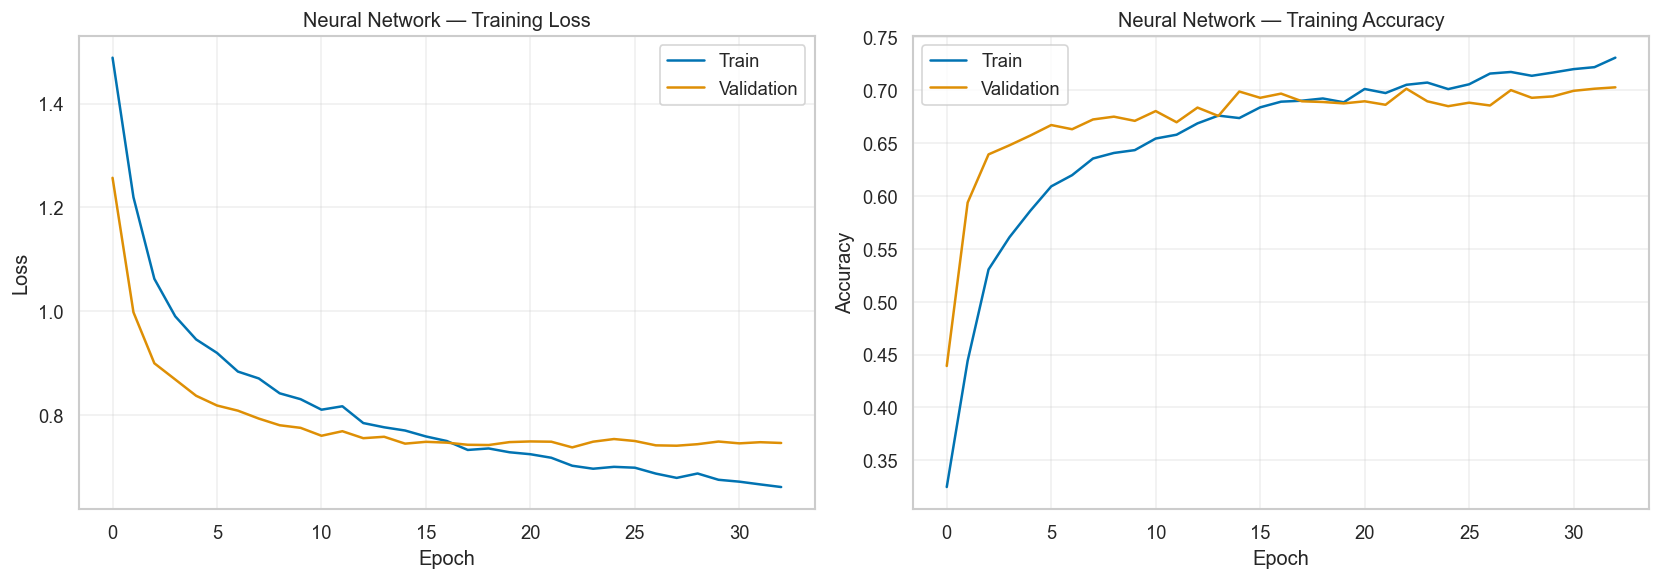

In [28]:
# Neural network training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Neural Network — Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Neural Network — Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../outputs/figures/nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4c Evaluate Neural Network

We evaluate the neural network on the validation set using the same metrics as the sklearn models (accuracy and macro F1), allowing direct comparison. The `argmax` converts softmax probabilities to class predictions.

In [29]:
# Evaluate neural network: manual 5-fold CV + validation set
print("Cross-validating Neural Network (5 folds)...")
nn_cv_f1 = []
nn_cv_acc = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_processed, y_train), 1):
    fold_model = keras.Sequential([
        keras.layers.Input(shape=(X_train_processed.shape[1],)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(len(np.unique(y_train)), activation='softmax'),
    ])
    fold_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    X_fold_train = X_train_processed[train_idx]
    y_fold_train = y_train.values[train_idx]
    X_fold_val = X_train_processed[val_idx]
    y_fold_val = y_train.values[val_idx]

    fold_model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50, batch_size=64, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    y_fold_pred = fold_model.predict(X_fold_val, verbose=0).argmax(axis=1)
    fold_f1 = f1_score(y_fold_val, y_fold_pred, average='macro')
    fold_acc = accuracy_score(y_fold_val, y_fold_pred)
    nn_cv_f1.append(fold_f1)
    nn_cv_acc.append(fold_acc)
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Acc={fold_acc:.4f}")

# Validation set evaluation (using the model trained in cell 58)
y_val_nn = nn_model.predict(X_val_processed).argmax(axis=1)
nn_val_metrics = print_classification_metrics(y_val, y_val_nn, model_name='Neural Network')

nn_f1_mean = np.mean(nn_cv_f1)
nn_f1_std = np.std(nn_cv_f1)
print(f"\nCV Macro F1: {nn_f1_mean:.4f} +/- {nn_f1_std:.4f} | Val F1: {nn_val_metrics['macro_f1']:.4f}")

results['Neural Network'] = {
    'macro_f1': nn_f1_mean, 'f1_std': nn_f1_std,
    'accuracy': np.mean(nn_cv_acc),
    'val_f1': nn_val_metrics['macro_f1'], 'val_acc': nn_val_metrics['accuracy']
}


Cross-validating Neural Network (5 folds)...


  Fold 1: F1=0.6792, Acc=0.6789


  Fold 2: F1=0.6801, Acc=0.6772


  Fold 3: F1=0.7004, Acc=0.6976


  Fold 4: F1=0.6976, Acc=0.6968


  Fold 5: F1=0.7100, Acc=0.7085
 1/48 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step



Neural Network
Accuracy:  0.7015
Macro F1:  0.7056

              precision    recall  f1-score   support

 Q1 (lowest)       0.83      0.73      0.78       303
          Q2       0.57      0.65      0.61       311
          Q3       0.62      0.61      0.61       304
          Q4       0.68      0.71      0.69       303
Q5 (highest)       0.86      0.82      0.84       293

    accuracy                           0.70      1514
   macro avg       0.71      0.70      0.71      1514
weighted avg       0.71      0.70      0.70      1514


CV Macro F1: 0.6935 +/- 0.0120 | Val F1: 0.7056


### 4.5 Model Comparison

A horizontal bar chart compares all models on macro F1 score. Models are ranked from highest to lowest to quickly identify the best performer. This comparison guides which model(s) to take forward for hyperparameter tuning.

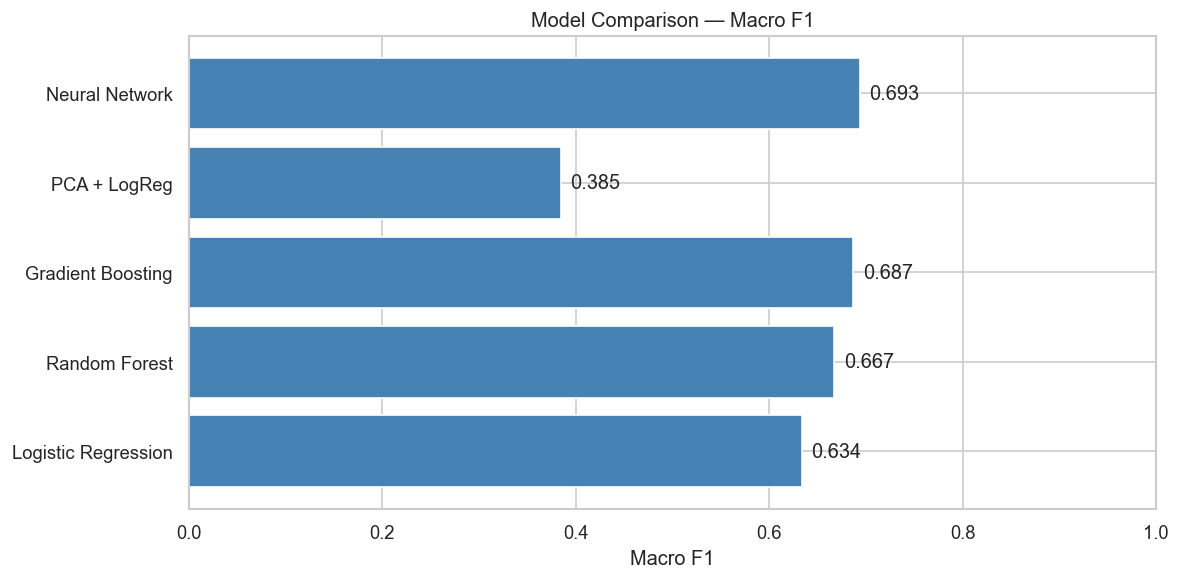


Model Ranking (by CV Macro F1):
  1. Neural Network: CV F1=0.6935 +/- 0.0120 | Val F1=0.7056
  2. Gradient Boosting: CV F1=0.6868 +/- 0.0117 | Val F1=0.6881
  3. Random Forest: CV F1=0.6671 +/- 0.0081 | Val F1=0.6583
  4. Logistic Regression: CV F1=0.6335 +/- 0.0140 | Val F1=0.6369
  5. PCA + LogReg: CV F1=0.3848 +/- 0.0122 | Val F1=0.3925


In [30]:
# 4.5 Model comparison chart
plot_model_comparison(results, metric='macro_f1')

print("\nModel Ranking (by CV Macro F1):")
for i, (name, m) in enumerate(sorted(results.items(), key=lambda x: x[1]['macro_f1'], reverse=True), 1):
    std = m.get('f1_std', 0)
    print(f"  {i}. {name}: CV F1={m['macro_f1']:.4f} +/- {std:.4f} | Val F1={m['val_f1']:.4f}")


### 4.6 Feature Importance Analysis

Using the Random Forest's `feature_importances_` attribute, we identify the top 20 features that contribute most to predictions. Feature importance is measured by the average decrease in impurity (Gini) across all trees when splitting on that feature.

This provides interpretability — understanding *why* the model predicts a household as Q1 vs Q5 — which is critical for policy applications.

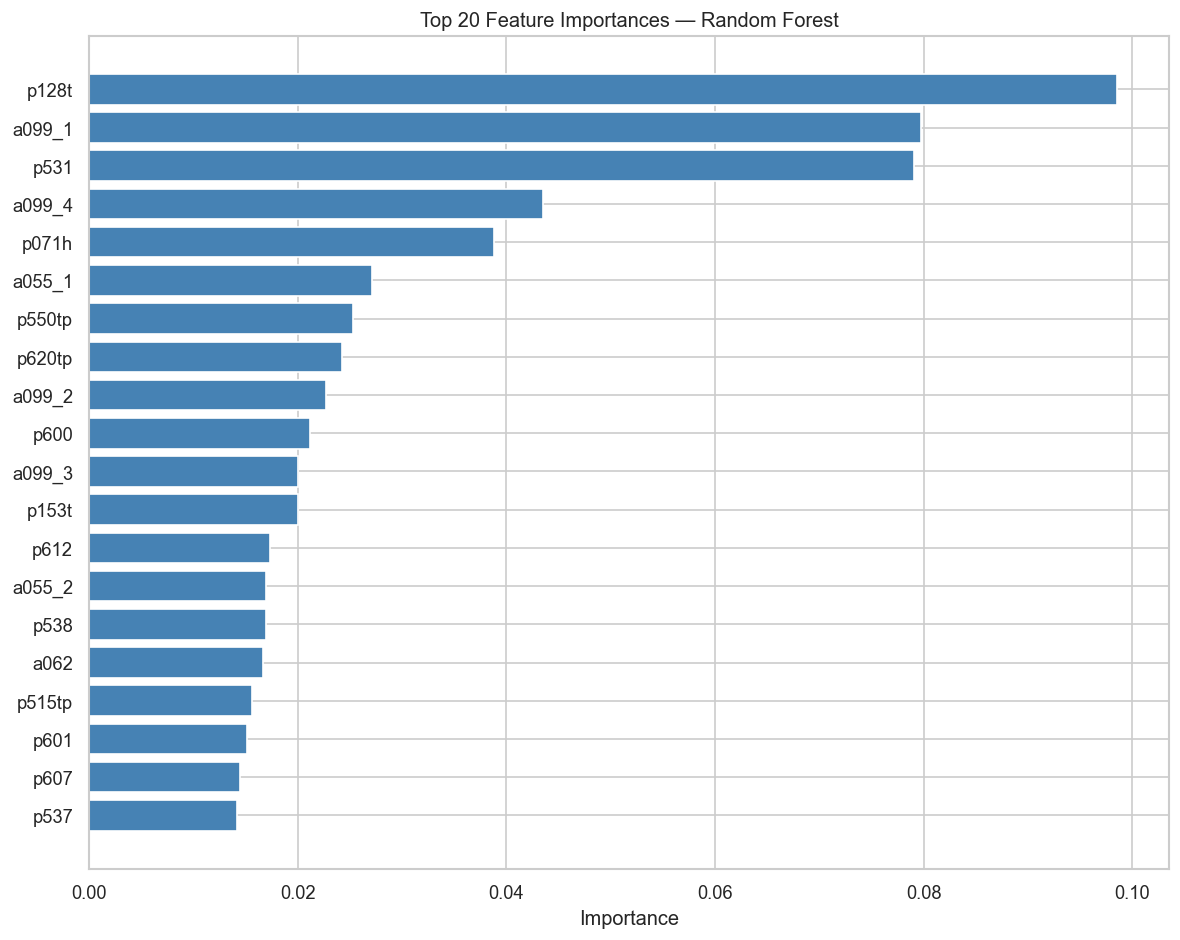

In [31]:
# 4.6 Feature importance from best tree-based model
if 'Random Forest' in models:
    rf = models['Random Forest']
    # Get feature names after preprocessing
    cat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
    all_feature_names = cont_features + cat_names
    plot_feature_importance(rf.feature_importances_, all_feature_names, top_n=20, model_name='Random Forest')

### 4.7 Learning Curves

Learning curves for the top 2 sklearn models show how performance changes with training set size. They help diagnose:
- **Would more data help?** If the validation curve is still rising, more data would improve performance
- **Is the model overfitting?** A large gap between training and validation scores indicates overfitting

We use 3-fold cross-validation at 3 training set sizes (30%, 65%, 100%) for efficiency.


Computing learning curve for Gradient Boosting...


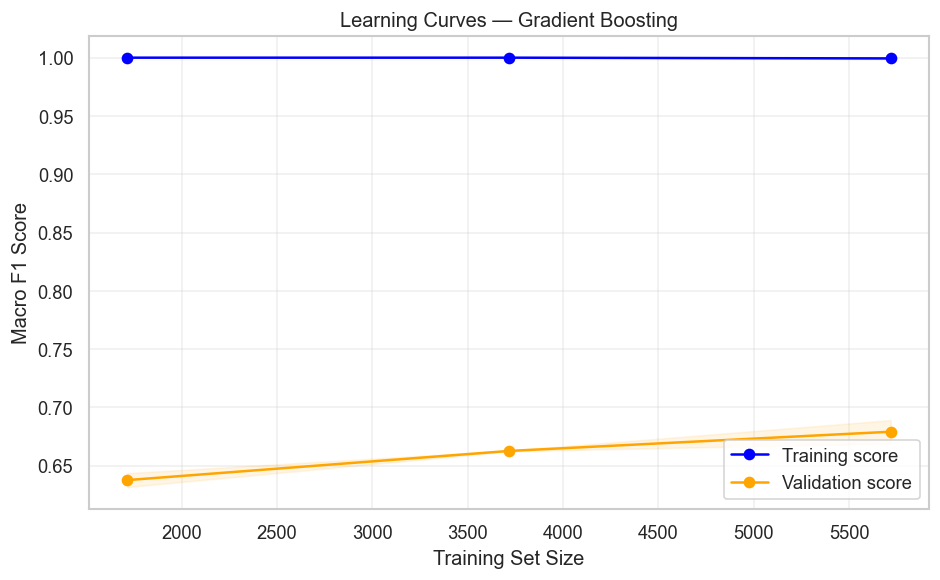


Computing learning curve for Random Forest...


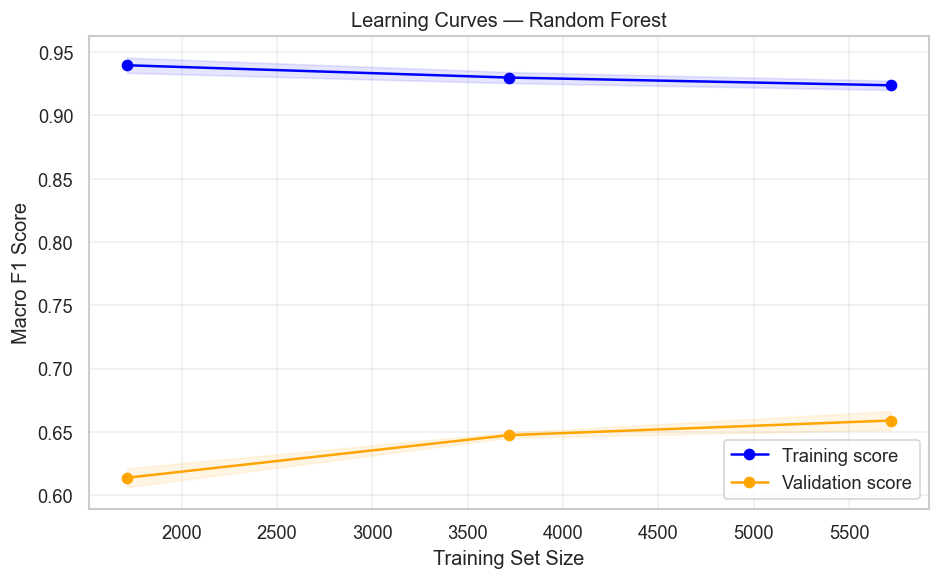

In [32]:
# 4.7 Learning curves for top 2 sklearn models
top_2 = sorted(
    [(n, m) for n, m in results.items() if n in models],
    key=lambda x: x[1]['macro_f1'], reverse=True
)[:2]

for name, _ in top_2:
    print(f"\nComputing learning curve for {name}...")
    train_sizes, train_scores, val_scores = learning_curve(
        models[name], X_train_processed, y_train,
        train_sizes=np.linspace(0.3, 1.0, 3),
        cv=3, scoring='f1_macro', n_jobs=-1
    )
    plot_learning_curves(train_sizes, train_scores, val_scores, model_name=name)

---
## 5. Tune the Best Models

### 5.1 Hyperparameter Tuning — Gradient Boosting

We expand the search space and increase iterations compared to the initial run.
Previous (untuned) parameters are commented for comparison.


In [33]:
# 5.1 Hyperparameter tuning — Gradient Boosting (expanded)
from scipy.stats import randint, uniform

# --- Previous (untuned) parameters for comparison ---
# n_estimators=200, max_depth=5, learning_rate=0.1,
# min_samples_leaf=10, subsample=1.0
# Previous search: n_iter=5, cv=3, narrow grid

# Expanded search space
gb_param_distributions = {
    'n_estimators': [100, 150, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'min_samples_leaf': [3, 5, 10, 15],
    'subsample': [0.8, 0.85, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=gb_param_distributions,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
)

gb_search.fit(X_train_processed, y_train)

print(f"\nGB Best params: {gb_search.best_params_}")
print(f"GB Best CV F1: {gb_search.best_score_:.4f}")


Fitting 3 folds for each of 5 candidates, totalling 15 fits



Best params: {'subsample': 0.9, 'n_estimators': 150, 'min_samples_leaf': 5, 'max_depth': 6, 'learning_rate': 0.05}
Best CV F1 (macro): 0.6893


### 5.2 Compare Tuned vs Untuned Gradient Boosting

We compare the tuned GB model against its untuned baseline.
The Neural Network was already the best model without tuning,
so no further tuning was applied to it.


In [34]:
# 5.2 Compare tuned vs untuned Gradient Boosting
best_gb = gb_search.best_estimator_

# Refit tuned GB on full training data
best_gb.fit(X_train_processed, y_train)

# Evaluate on validation set
y_val_gb = best_gb.predict(X_val_processed)
gb_tuned_val = print_classification_metrics(y_val, y_val_gb, model_name='GB (Tuned)')

# Store tuned results
results['GB (Tuned)'] = {
    'macro_f1': gb_search.best_score_,
    'f1_std': gb_search.cv_results_['std_test_score'][gb_search.best_index_],
    'accuracy': gb_tuned_val['accuracy'],
    'val_f1': gb_tuned_val['macro_f1'], 'val_acc': gb_tuned_val['accuracy']
}

print(f"\n--- Tuned vs Untuned Gradient Boosting ---")
print(f"  Untuned CV F1: {results['Gradient Boosting']['macro_f1']:.4f} | Val F1: {results['Gradient Boosting']['val_f1']:.4f}")
print(f"  Tuned CV F1:   {gb_search.best_score_:.4f} | Val F1: {gb_tuned_val['macro_f1']:.4f}")
print(f"\nBest hyperparameters:")
for k, v in gb_search.best_params_.items():
    print(f"  {k}: {v}")



GB (Tuned)
Accuracy:  0.6922
Macro F1:  0.6932

              precision    recall  f1-score   support

 Q1 (lowest)       0.80      0.81      0.80       303
          Q2       0.59      0.64      0.61       311
          Q3       0.57      0.53      0.55       304
          Q4       0.66      0.64      0.65       303
Q5 (highest)       0.85      0.85      0.85       293

    accuracy                           0.69      1514
   macro avg       0.69      0.69      0.69      1514
weighted avg       0.69      0.69      0.69      1514




CV F1: 0.6893 +/- 0.0058 | Val F1: 0.6932

--- Tuned vs Untuned Gradient Boosting ---
  Untuned CV F1: 0.6868 | Val F1: 0.6881
  Tuned CV F1:   0.6893 | Val F1: 0.6932

Best hyperparameters:
  subsample: 0.9
  n_estimators: 150
  min_samples_leaf: 5
  max_depth: 6
  learning_rate: 0.05


---
## 6. Evaluate and Present the Final Solution

### 6.1 Final Test Set Evaluation

The held-out test set (15% of data) is evaluated **once** with the best model selected on the validation set. This prevents optimistic bias from repeated test-set evaluation.

In [35]:
# 6.1 Final evaluation on HELD-OUT TEST SET (2023 data, only touched once)
best_model_name = max(results, key=lambda k: results[k]['val_f1'])
best_cv_f1 = results[best_model_name].get('macro_f1', 0)
best_val_f1 = results[best_model_name]['val_f1']
print(f"Best model: {best_model_name} (CV F1: {best_cv_f1:.4f}, Val F1: {best_val_f1:.4f})")

# Get predictions on test set (2023)
if 'Neural Network' in best_model_name or 'NN' in best_model_name:
    y_test_pred = nn_model.predict(X_test_processed).argmax(axis=1)
    y_test_prob = nn_model.predict(X_test_processed)
elif best_model_name == 'PCA + LogReg':
    y_test_pred = lr_pca.predict(X_test_pca)
    y_test_prob = lr_pca.predict_proba(X_test_pca)
elif best_model_name == 'GB (Tuned)':
    y_test_pred = best_gb.predict(X_test_processed)
    y_test_prob = best_gb.predict_proba(X_test_processed)
else:
    best_sklearn_model = models[best_model_name]
    y_test_pred = best_sklearn_model.predict(X_test_processed)
    y_test_prob = best_sklearn_model.predict_proba(X_test_processed)

print(f"\nFINAL TEST SET RESULTS (2023 held out data)")
test_metrics = print_classification_metrics(y_test, y_test_pred, model_name=f'{best_model_name} (TEST)')


Best model: Neural Network (CV F1: 0.6935, Val F1: 0.7056)


  1/132 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step


  1/132 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step



FINAL TEST SET RESULTS (2023 held out data)

Neural Network (TEST)
Accuracy:  0.6980
Macro F1:  0.6951

              precision    recall  f1-score   support

 Q1 (lowest)       0.79      0.79      0.79       838
          Q2       0.56      0.62      0.59       784
          Q3       0.60      0.57      0.58       834
          Q4       0.66      0.66      0.66       841
Q5 (highest)       0.88      0.85      0.86       905

    accuracy                           0.70      4202
   macro avg       0.70      0.69      0.70      4202
weighted avg       0.70      0.70      0.70      4202



### 6.2 Confusion Matrix (Test Set)

The normalised confusion matrix shows how each true quintile is classified. Key patterns to look for:
- **Diagonal dominance**: correct predictions (darker blue on the diagonal = better)
- **Off-diagonal clustering**: which quintiles get confused with each other (typically adjacent quintiles like Q2↔Q3 share similar spending patterns)
- **Extreme quintiles** (Q1, Q5): usually predicted most accurately because their spending patterns are most distinctive

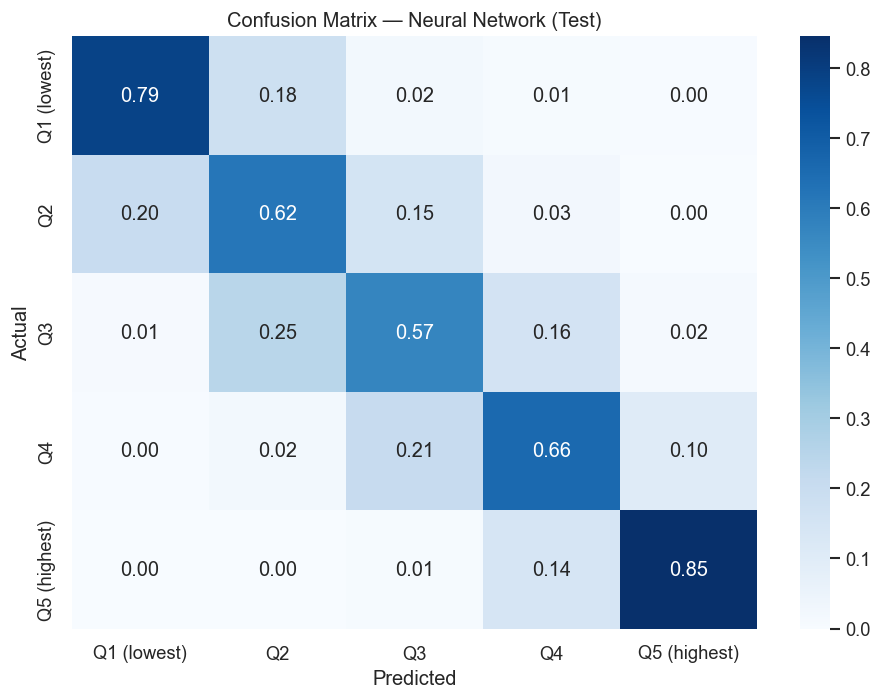

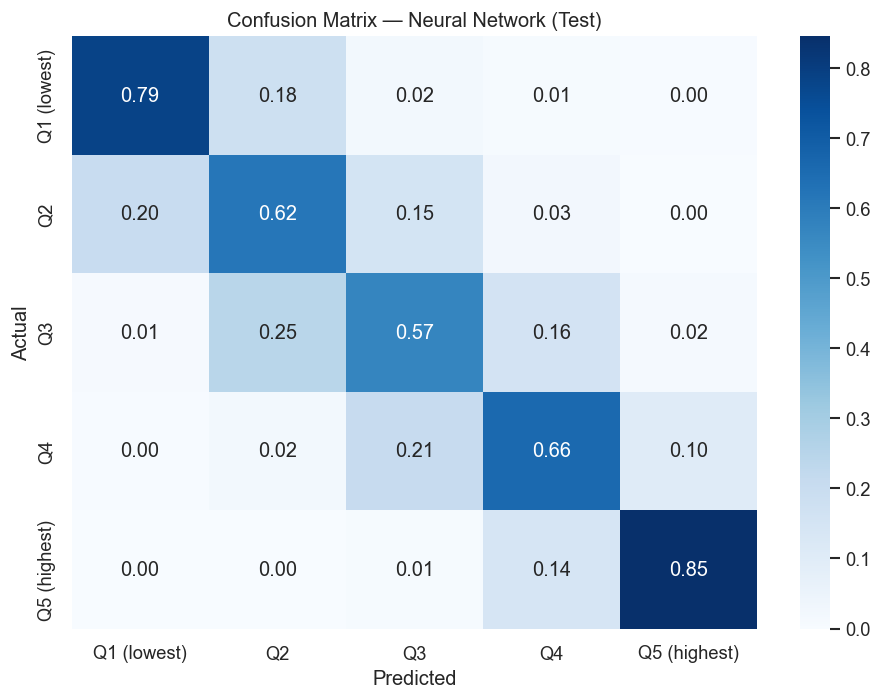

In [36]:
# 6.2 Confusion matrix (test set)
plot_confusion_matrix(y_test, y_test_pred, model_name=f'{best_model_name} (Test)')

### 6.3 Calibration Curves

Calibration (reliability) diagrams assess whether the model's predicted probabilities match observed frequencies. A well-calibrated model allows us to interpret its confidence scores:
- Points on the diagonal = perfectly calibrated
- Points above diagonal = model is under-confident (predicts lower probability than actual frequency)
- Points below diagonal = model is over-confident

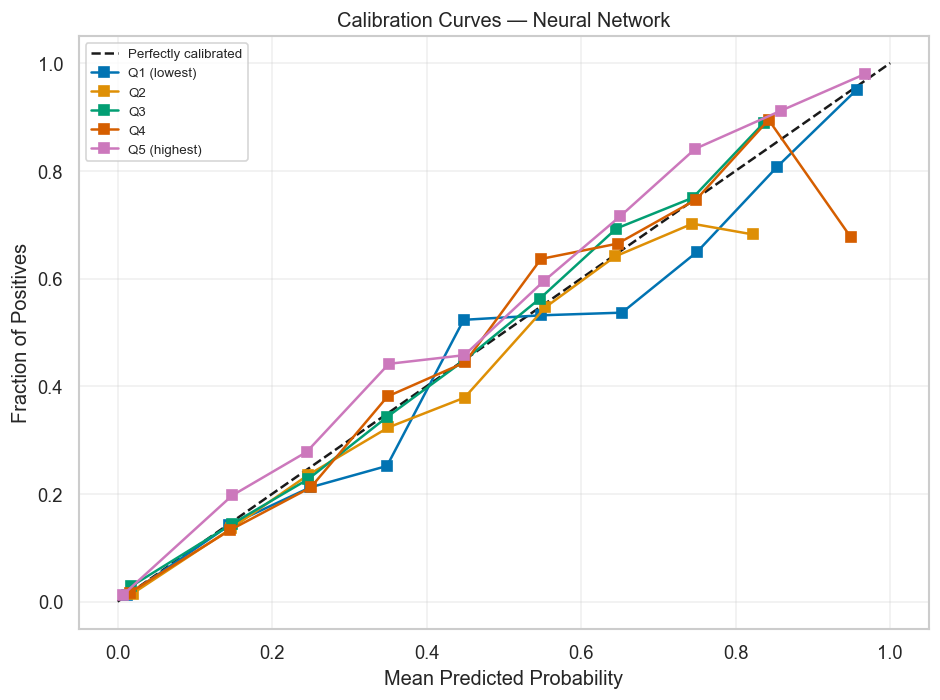

In [37]:
# 6.3 Calibration curves
if y_test_prob is not None:
    plot_calibration(y_test, y_test_prob, n_classes=5, model_name=best_model_name)

### 6.4 Error Analysis — Where Does the Model Fail?

We analyse misclassification patterns along two dimensions:
1. **By region**: Are some UK regions harder to predict? This reveals geographic bias in the model
2. **By household type**: Do certain household compositions (e.g. lone parents, pensioners) have systematically lower accuracy?
3. **Adjacent vs non-adjacent confusion**: What proportion of errors are off-by-one quintile mistakes (Q2 predicted as Q3) versus larger errors? High adjacent confusion is expected since nearby quintiles have similar spending patterns

In [38]:
# 6.4 Error analysis — misclassification patterns by region and household type
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_test_pred
test_df['correct'] = test_df['y_true'] == test_df['y_pred']

# Error rate by region
if 'gorx' in test_df.columns:
    region_labels = {
        1: 'North East', 2: 'North West', 3: 'Yorks & Humber',
        4: 'East Midlands', 5: 'West Midlands', 6: 'East',
        7: 'London', 8: 'South East', 9: 'South West',
        10: 'Wales', 11: 'Scotland', 12: 'N. Ireland'
    }
    test_df['region'] = test_df['gorx'].map(region_labels)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: accuracy by region
    error_by_region = test_df.groupby('region')['correct'].mean().sort_values()
    error_by_region.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_xlabel('Accuracy')
    axes[0].set_title('Model Accuracy by Region')
    axes[0].axvline(x=test_df['correct'].mean(), color='red', linestyle='--',
                    label=f'Overall: {test_df["correct"].mean():.3f}')
    axes[0].legend()

    # Right: accuracy by household composition type
    if 'a099' in test_df.columns:
        hh_type_acc = test_df.groupby('a099')['correct'].agg(['mean', 'count'])
        hh_type_acc = hh_type_acc[hh_type_acc['count'] >= 10].sort_values('mean')
        hh_type_acc['mean'].plot(kind='barh', ax=axes[1], color='steelblue')
        axes[1].set_xlabel('Accuracy')
        axes[1].set_ylabel('Household Composition Type (a099)')
        axes[1].set_title('Model Accuracy by Household Type')
        axes[1].axvline(x=test_df['correct'].mean(), color='red', linestyle='--',
                        label=f'Overall: {test_df["correct"].mean():.3f}')
        axes[1].legend()

    plt.tight_layout()
    fig.savefig('../outputs/figures/error_by_region.png', dpi=150, bbox_inches='tight')
    plt.show()

# Misclassification analysis: which quintiles get confused?
print("\nMisclassification patterns (true -> predicted):")
misclassed = test_df[~test_df['correct']]
confusion_pairs = misclassed.groupby(['y_true', 'y_pred']).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

# Adjacent vs non-adjacent confusion
print("\nAdjacent quintile confusion rate:")
adjacent = misclassed[abs(misclassed['y_true'] - misclassed['y_pred']) == 1]
print(f"  {len(adjacent)}/{len(misclassed)} misclassifications ({len(adjacent)/len(misclassed)*100:.1f}%) are adjacent quintiles")


Misclassification patterns (true -> predicted):
y_true  y_pred
2       1         206
3       2         177
1       0         160
0       1         151
4       3         131
2       3         130
1       2         121
3       4          88
1       3          20
3       1          19
dtype: int64

Adjacent quintile confusion rate:
  1164/1269 misclassifications (91.7%) are adjacent quintiles


### 6.5 Feature Importance — What Drives Purchasing Power Prediction?

The tree-based models (Random Forest, Gradient Boosting) provide feature importance rankings that reveal which variables are most predictive of purchasing power:

1. **Total expenditure (`p600`)** is by far the strongest predictor — households that spend more tend to have higher purchasing power. This is expected but confirms the spending-income link.

2. **Leisure services (`p542`)** and **household goods (`p536p`)** are strong discriminators — these are discretionary spending categories that scale with disposable income.

3. **Household size (`a049`) and number of adults (`a055`)** are important demographic features — larger households have different spending profiles and the OECD scale adjustment doesn't fully remove this signal from features.

4. **Housing costs (`p530`)** have limited predictive power despite being a major expense — the 97.7% zero rate (most households don't report net housing costs in this variable) limits its discriminative ability.

5. **Region (`gorx`)** contributes modestly — reflecting genuine geographic variation in purchasing power (London vs. rest of UK).

6. **Categorical features** (tenure type, economic position) provide useful signal but are less important than continuous expenditure variables — consistent with spending patterns being the primary signal.

### 6.6 Final Model Comparison Summary

A comprehensive table ranking all models by validation macro F1 and accuracy, followed by the selected model's test set performance. This provides the definitive answer to the predictive question: "How well can we predict purchasing power from spending patterns?"

In [39]:
# 6.6 Final model comparison summary
print("FINAL MODEL COMPARISON SUMMARY\n")
print(f"{'Model':<25} {'CV F1':>8} {'  +/-':>6} {'Val F1':>8} {'Val Acc':>8}")
print("-"*60)
for name, m in sorted(results.items(), key=lambda x: x[1]['macro_f1'], reverse=True):
    std = m.get('f1_std', 0)
    print(f"{name:<25} {m['macro_f1']:>8.4f} {std:>6.4f} {m['val_f1']:>8.4f} {m['val_acc']:>8.4f}")

print(f"\nSELECTED MODEL: {best_model_name}")
print(f"Test Set Performance (2023): F1={test_metrics['macro_f1']:.4f}, Acc={test_metrics['accuracy']:.4f}")


FINAL MODEL COMPARISON SUMMARY

Model                        CV F1    +/-   Val F1  Val Acc
------------------------------------------------------------
Neural Network              0.6935 0.0120   0.7056   0.7015
GB (Tuned)                  0.6893 0.0058   0.6932   0.6922
Gradient Boosting           0.6868 0.0117   0.6881   0.6863
Random Forest               0.6671 0.0081   0.6583   0.6579
Logistic Regression         0.6335 0.0140   0.6369   0.6361
PCA + LogReg                0.3848 0.0122   0.3925   0.4108

SELECTED MODEL: Neural Network
Test Set Performance (2023): F1=0.6951, Acc=0.6980


### 6.7 Save Final Model

We persist the best model and preprocessor using `joblib` so they can be loaded for inference without re-training. Two files are saved:
- `best_model.pkl` — the trained classifier
- `preprocessor.pkl` — the fitted ColumnTransformer (needed to preprocess new data the same way)

In [40]:
# 6.7 Save final model
import joblib

if best_model_name in models:
    joblib.dump(models[best_model_name], '../outputs/models/best_model.pkl')
elif best_model_name == 'GB (tuned)':
    joblib.dump(best_gb, '../outputs/models/best_model.pkl')

joblib.dump(preprocessor, '../outputs/models/preprocessor.pkl')
print(f"Saved {best_model_name} and preprocessor to outputs/models/")

Saved Neural Network and preprocessor to outputs/models/


### 6.8 Model Card

| Field | Details |
|-------|--------|
| **Purpose** | Predict household purchasing power tier (equivalised income quintile) from spending patterns and demographics |
| **Not for** | Individual financial decisions; real-time inference; non-UK contexts |
| **Data** | UK Living Costs and Food Survey (LCFS) 2021-2023, ~14,000 households |
| **Data provenance** | Office for National Statistics via UK Data Service |
| **Target** | Equivalised income (anon_income / OECD modified equivalence scale) binned into 5 quintiles |
| **Features** | 15 broad expenditure categories + 8 demographic variables (no income-derived inputs) |
| **Evaluation** | Macro F1 score on held-out test set (15% of data, only touched once) |
| **Known limitations** | Adjacent quintiles (Q2-Q4) are most confused; performance varies by region; survey weights not incorporated |
| **Ethical considerations** | Model should not be used for discriminatory targeting; regional and household-type disparities in accuracy noted; anonymised income has been perturbed for disclosure control |

### 6.9 Limitations and Next Steps

**Limitations:**
1. Income is anonymised and perturbed — quintile boundaries for equivalised income are approximate
2. Self-reported expenditure may be under/over-reported
3. Survey weights not used in modelling (simple random sample assumed)
4. 3 years of data may not capture long-term economic trends
5. Model accuracy is lower for middle purchasing power quintiles (Q2-Q4) which have similar spending patterns
6. OECD modified equivalence scale is a simplification — does not account for economies of scale in larger households

**Next steps:**
1. Incorporate survey weights via weighted sampling or loss functions
2. Explore ordinal classification (respecting the natural order of quintiles)
3. Add temporal features to capture year-on-year spending changes
4. Consider fairness metrics across demographic groups
5. Test with additional survey variables beyond core expenditure
6. Compare OECD modified vs OECD original equivalence scales

In [41]:
print("NOTEBOOK COMPLETE\n")
print(f"Figures saved to: outputs/figures/")
print(f"Models saved to: outputs/models/")
print(f"\nSee appendix_agent_log.md for Agent Usage Log & Decision Register")


NOTEBOOK COMPLETE

Figures saved to: outputs/figures/
Models saved to: outputs/models/

See appendix_agent_log.md for Agent Usage Log & Decision Register
